# Home Credit Default Risk — Exploratory Data Analysis

**Objective:** Predict whether a loan applicant will default (TARGET=1) or repay (TARGET=0).

This notebook performs a comprehensive EDA across all 8 data tables provided by Home Credit:

1. `application_train.csv` — Main training data with TARGET
2. `application_test.csv` — Test data (no TARGET)
3. `bureau.csv` — Credits from other institutions (Credit Bureau)
4. `bureau_balance.csv` — Monthly bureau credit history
5. `previous_application.csv` — Previous Home Credit applications
6. `POS_CASH_balance.csv` — POS / cash loan monthly snapshots
7. `credit_card_balance.csv` — Credit card monthly snapshots
8. `installments_payments.csv` — Repayment history

**Relationship Map:**
```
application_train/test ──(SK_ID_CURR)──► bureau ──(SK_ID_BUREAU)──► bureau_balance
application_train/test ──(SK_ID_CURR)──► previous_application
                                           ├─(SK_ID_PREV)──► POS_CASH_balance
                                           ├─(SK_ID_PREV)──► credit_card_balance
                                           └─(SK_ID_PREV)──► installments_payments
```

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip /content/drive/MyDrive/home-credit-default-risk.zip

Archive:  /content/drive/MyDrive/home-credit-default-risk.zip
   creating: home-credit-default-risk/
  inflating: __MACOSX/._home-credit-default-risk  
  inflating: home-credit-default-risk/analyze_hc.py  
  inflating: home-credit-default-risk/application_test.csv  
  inflating: __MACOSX/home-credit-default-risk/._application_test.csv  
  inflating: home-credit-default-risk/HomeCredit_columns_description.csv  
  inflating: __MACOSX/home-credit-default-risk/._HomeCredit_columns_description.csv  
  inflating: home-credit-default-risk/POS_CASH_balance.csv  
  inflating: __MACOSX/home-credit-default-risk/._POS_CASH_balance.csv  
  inflating: home-credit-default-risk/credit_card_balance.csv  
  inflating: __MACOSX/home-credit-default-risk/._credit_card_balance.csv  
  inflating: home-credit-default-risk/installments_payments.csv  
  inflating: __MACOSX/home-credit-default-risk/._installments_payments.csv  
  inflating: home-credit-default-risk/application_train.csv  
  inflating: __MACOSX/h

In [34]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
pd.set_option("display.max_columns", 50)

DATA_DIR = "/content/home-credit-default-risk"
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load the Datasets & Overview

In [35]:
# Load all datasets
train = pd.read_csv(f"{DATA_DIR}/application_train.csv", encoding="latin-1")
test = pd.read_csv(f"{DATA_DIR}/application_test.csv", encoding="latin-1")

# Print overview of all tables
datasets = {
    "application_train": train,
    "application_test": test,
}
# Show shapes and file sizes
print(f"{'Table':<30} {'Rows':>10} {'Cols':>6} {'Size (MB)':>10}")
print("-" * 60)
for name, df in datasets.items():
    fpath = f"{DATA_DIR}/{name}.csv"
    sz = os.path.getsize(fpath) / 1024 / 1024
    print(f"{name:<30} {df.shape[0]:>10,} {df.shape[1]:>6} {sz:>10.1f}")

# Show supplementary table sizes (loaded later as needed)
for fname in ["bureau.csv", "bureau_balance.csv", "previous_application.csv",
              "POS_CASH_balance.csv", "credit_card_balance.csv", "installments_payments.csv"]:
    fpath = f"{DATA_DIR}/{fname}"
    sz = os.path.getsize(fpath) / 1024 / 1024
    print(f"{fname.replace('.csv',''):<30} {'—':>10} {'—':>6} {sz:>10.1f}")

Table                                Rows   Cols  Size (MB)
------------------------------------------------------------
application_train                 307,511    122      158.4
application_test                   48,744    121       25.3
bureau                                  —      —      162.1
bureau_balance                          —      —      358.2
previous_application                    —      —      386.2
POS_CASH_balance                        —      —      374.5
credit_card_balance                     —      —      404.9
installments_payments                   —      —      689.6


In [36]:
# Preview the training data
print(f"Training data: {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"Unique applicants: {train['SK_ID_CURR'].nunique():,}")
train.head()

Training data: 307,511 rows × 122 columns
Unique applicants: 307,511


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
# Data types and info
print("Column Types:")
print(train.dtypes.value_counts())
print(f"\nCategorical columns: {train.select_dtypes(include='object').columns.tolist()}")
print(f"\nNumeric columns count: {len(train.select_dtypes(include=[np.number]).columns)}")
train.info(verbose=False)

Column Types:
float64    65
int64      41
object     16
Name: count, dtype: int64

Categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

Numeric columns count: 106
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [38]:
# Summary statistics for key numeric columns
train[["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE",
       "DAYS_BIRTH", "DAYS_EMPLOYED", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].describe()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000
mean,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,-16036.995067,63815.045904,0.502130,5.143927e-01,0.510853
std,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,4363.988632,141275.766519,0.211062,1.910602e-01,0.194844
min,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,-25229.000000,-17912.000000,0.014568,8.173617e-08,0.000527
25%,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,-19682.000000,-2760.000000,0.334007,3.924574e-01,0.370650
50%,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,-15750.000000,-1213.000000,0.505998,5.659614e-01,0.535276
75%,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,-12413.000000,-289.000000,0.675053,6.636171e-01,0.669057
max,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,-7489.000000,365243.000000,0.962693,8.549997e-01,0.896010


## 3. Target Variable Analysis

The TARGET column indicates:
- **0** — Loan was repaid on time (no default)
- **1** — Loan was not repaid (default)

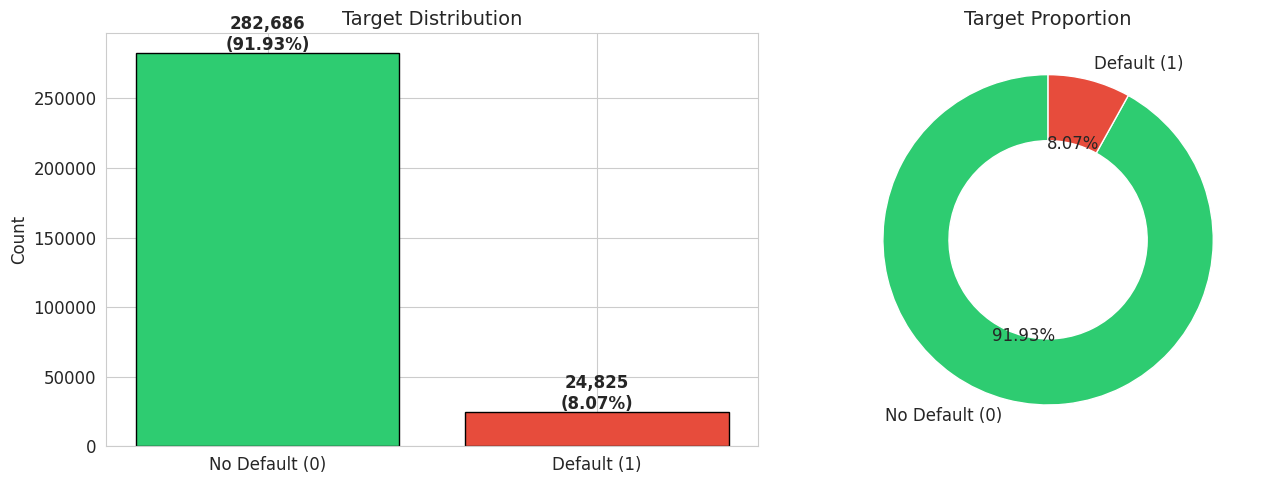


Imbalance ratio: 1:11 (non-default : default)
Default rate: 8.07%


In [ ]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
target_counts = train["TARGET"].value_counts()
colors = ["#2ecc71", "#e74c3c"]
axes[0].bar(["No Default (0)", "Default (1)"], target_counts.values, color=colors, edgecolor="black")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2000, f"{v:,}\n({v/len(train)*100:.2f}%)", ha="center", fontweight="bold")
axes[0].set_title("Target Distribution", fontsize=14)
axes[0].set_ylabel("Count")

# Donut chart
axes[1].pie(target_counts.values, labels=["No Default (0)", "Default (1)"],
            autopct="%1.2f%%", colors=colors, startangle=90,
            wedgeprops=dict(width=0.4, edgecolor="white"))
axes[1].set_title("Target Proportion", fontsize=14)

plt.tight_layout()
plt.show()

print(f"\nImbalance ratio: 1:{target_counts[0]//target_counts[1]} (non-default : default)")
print(f"Default rate: {train['TARGET'].mean()*100:.2f}%")

#in log reg and others, you can set class weights so it gives more weight to the minor class
#you cannot do smote for financial data (only okay if too less like 2%)
# generally, not supposed to do because rejection / default rates HAVE to be low. Hence, we cannot increase bcoz that'll imply we are more in loss than in profit for the business which si not ideal
# we dont want model to think 15% defaults is a good thing. 

## 4. Missing Values Analysis

Columns with missing values: 67 / 122
Columns with >40% missing:  49
Columns with >70% missing:  0
Columns with 0% missing:    55


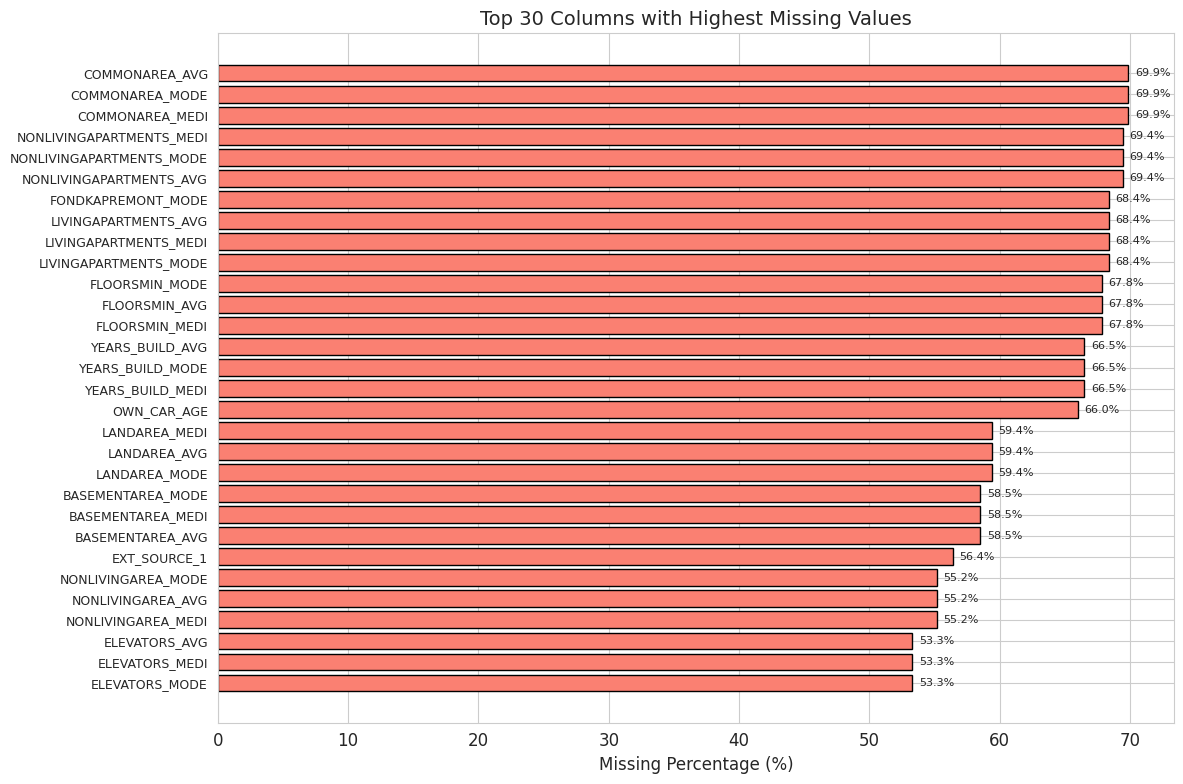

In [40]:
# Missing values percentage
null_pct = (train.isnull().mean() * 100).sort_values(ascending=False)
null_cols = null_pct[null_pct > 0]

print(f"Columns with missing values: {len(null_cols)} / {len(train.columns)}")
print(f"Columns with >40% missing:  {(null_pct > 40).sum()}")
print(f"Columns with >70% missing:  {(null_pct > 70).sum()}")
print(f"Columns with 0% missing:    {(null_pct == 0).sum()}")

# Plot top 30 columns by missing percentage
fig, ax = plt.subplots(figsize=(12, 8))
top_missing = null_cols.head(30)
bars = ax.barh(range(len(top_missing)), top_missing.values, color="salmon", edgecolor="black")
ax.set_yticks(range(len(top_missing)))
ax.set_yticklabels(top_missing.index, fontsize=9)
ax.set_xlabel("Missing Percentage (%)")
ax.set_title("Top 30 Columns with Highest Missing Values", fontsize=14)
ax.invert_yaxis()
for bar, val in zip(bars, top_missing.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

## 5. Univariate Analysis — Categorical Features

Analyzing key categorical features and their relationship with the default rate.

In [41]:
# Helper function: plot category counts with default rate
def plot_categorical(df, col, top_n=None, figsize=(14, 5)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Compute stats per category
    stats = df.groupby(col)["TARGET"].agg(["count", "mean"]).reset_index()
    stats.columns = [col, "count", "default_rate"]
    stats = stats.sort_values("count", ascending=False)
    if top_n:
        stats = stats.head(top_n)

    # Count plot
    colors_map = sns.color_palette("viridis", len(stats))
    axes[0].barh(stats[col].astype(str), stats["count"], color=colors_map, edgecolor="black")
    axes[0].set_xlabel("Count")
    axes[0].set_title(f"{col} — Distribution", fontsize=13)
    axes[0].invert_yaxis()

    # Default rate plot
    axes[1].barh(stats[col].astype(str), stats["default_rate"] * 100, color="salmon", edgecolor="black")
    axes[1].set_xlabel("Default Rate (%)")
    axes[1].set_title(f"{col} — Default Rate by Category", fontsize=13)
    axes[1].axvline(x=df["TARGET"].mean()*100, color="red", linestyle="--", label=f"Overall: {df['TARGET'].mean()*100:.2f}%")
    axes[1].legend()
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()

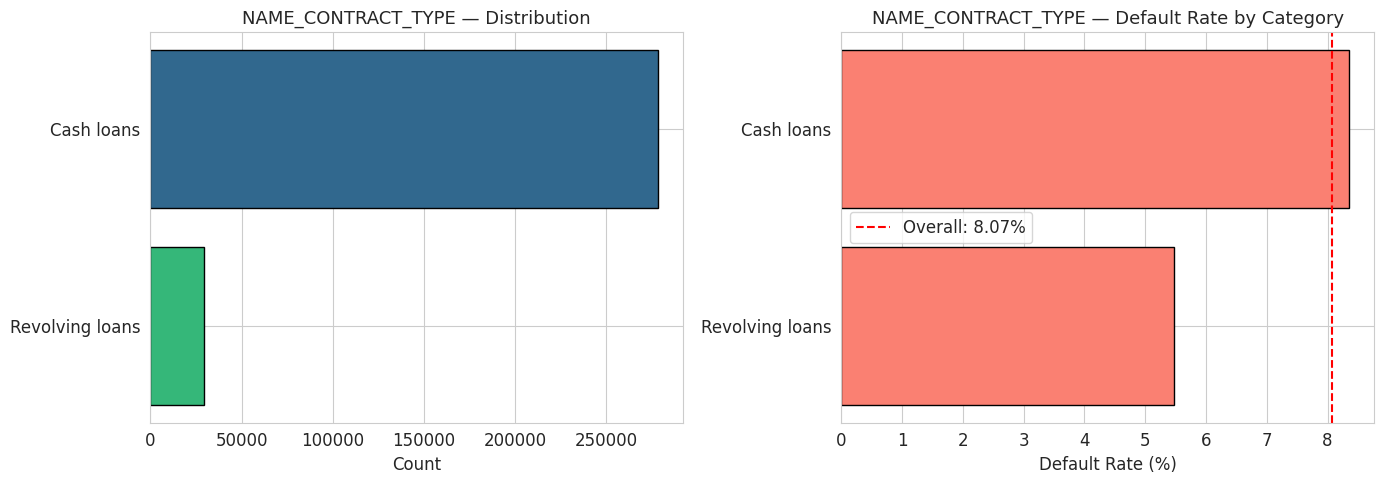

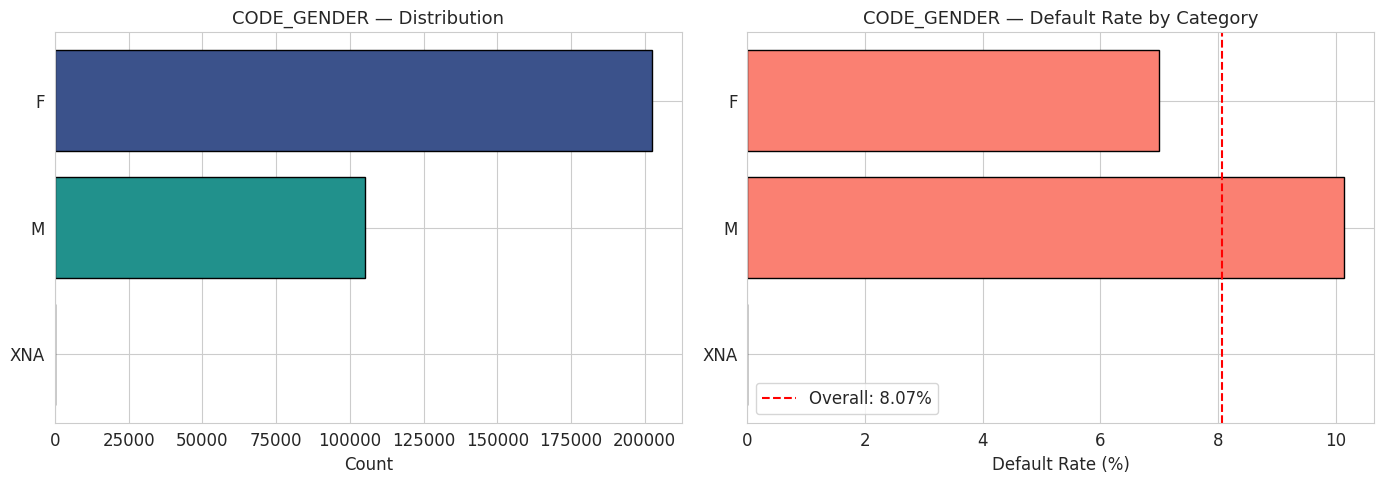

In [ ]:
# Contract Type & Gender
plot_categorical(train, "NAME_CONTRACT_TYPE")
plot_categorical(train, "CODE_GENDER")

#8% is default rate so anything above trhat is default
# so we can see that some classes are MORE than avg default rate and others aer lower

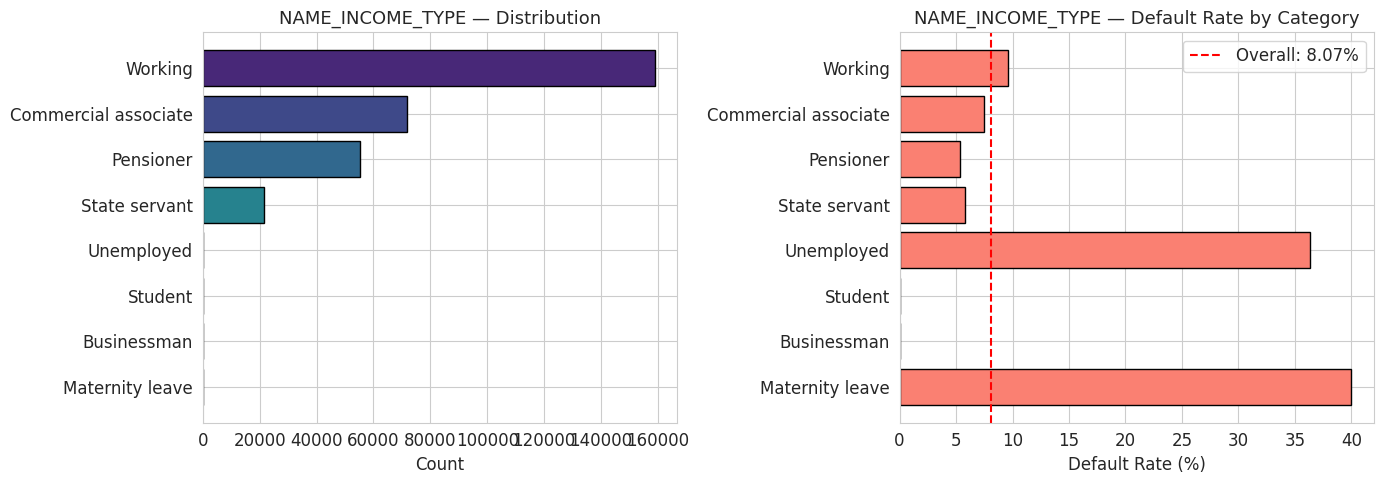

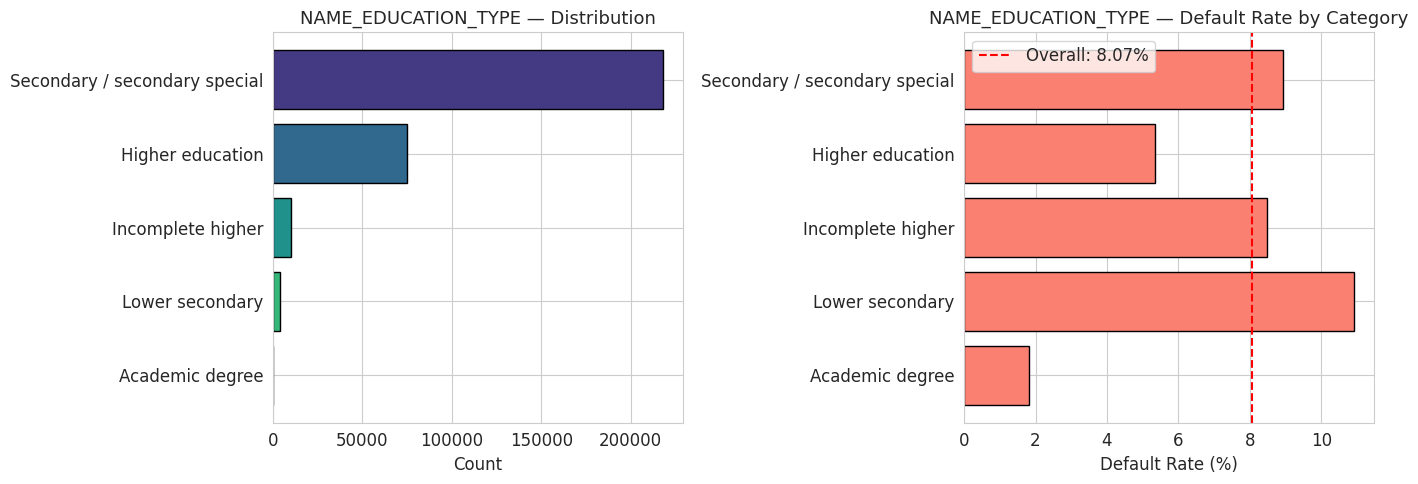

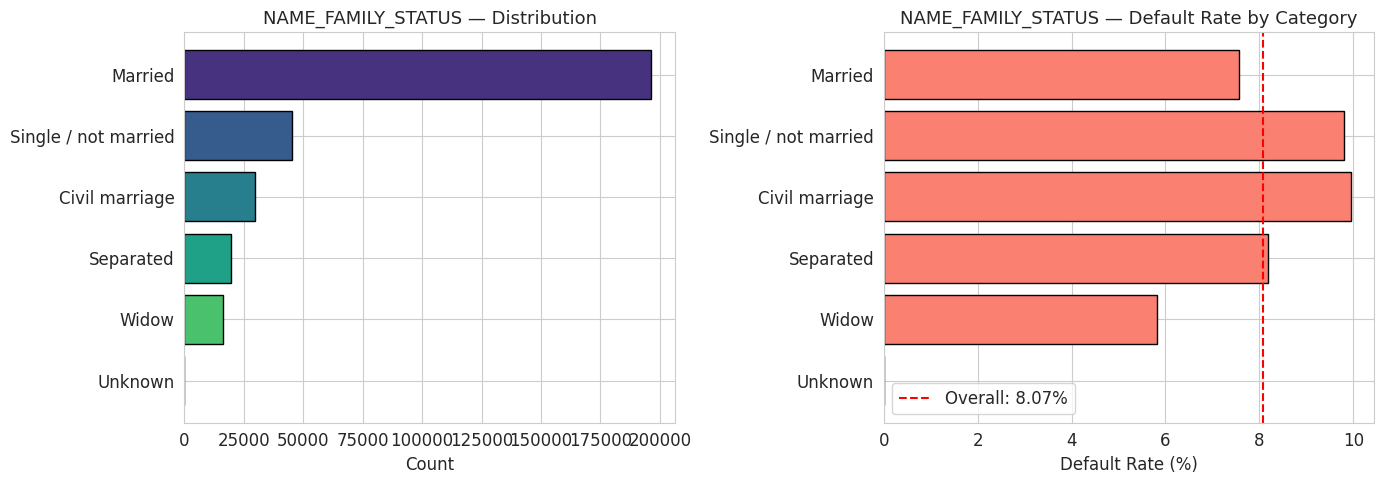

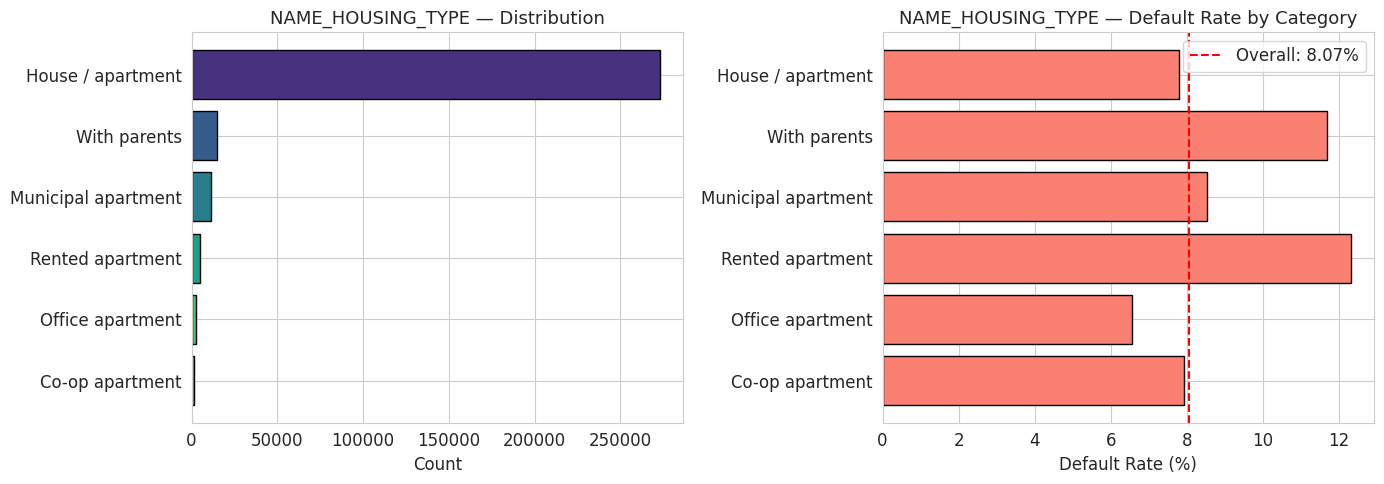

In [ ]:
# Income Type, Education, Family Status, Housing Type
plot_categorical(train, "NAME_INCOME_TYPE")
plot_categorical(train, "NAME_EDUCATION_TYPE")
plot_categorical(train, "NAME_FAMILY_STATUS")
plot_categorical(train, "NAME_HOUSING_TYPE")

#left is regular, right is normalised, and compared against the avg 8% default rate
# NOTE: PUT IN WORD,S HOW SOME CATEGORIES ARE MORE LIKELY TO DEFAULT THAN OTHERS

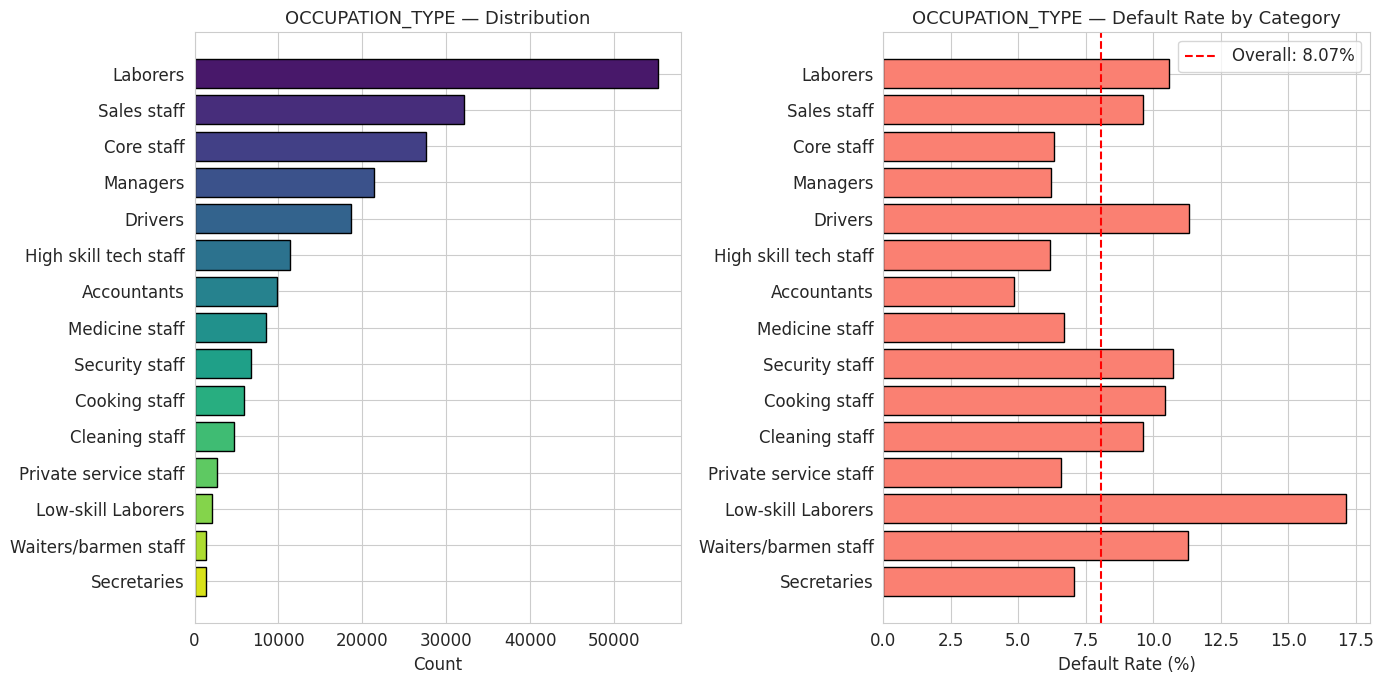

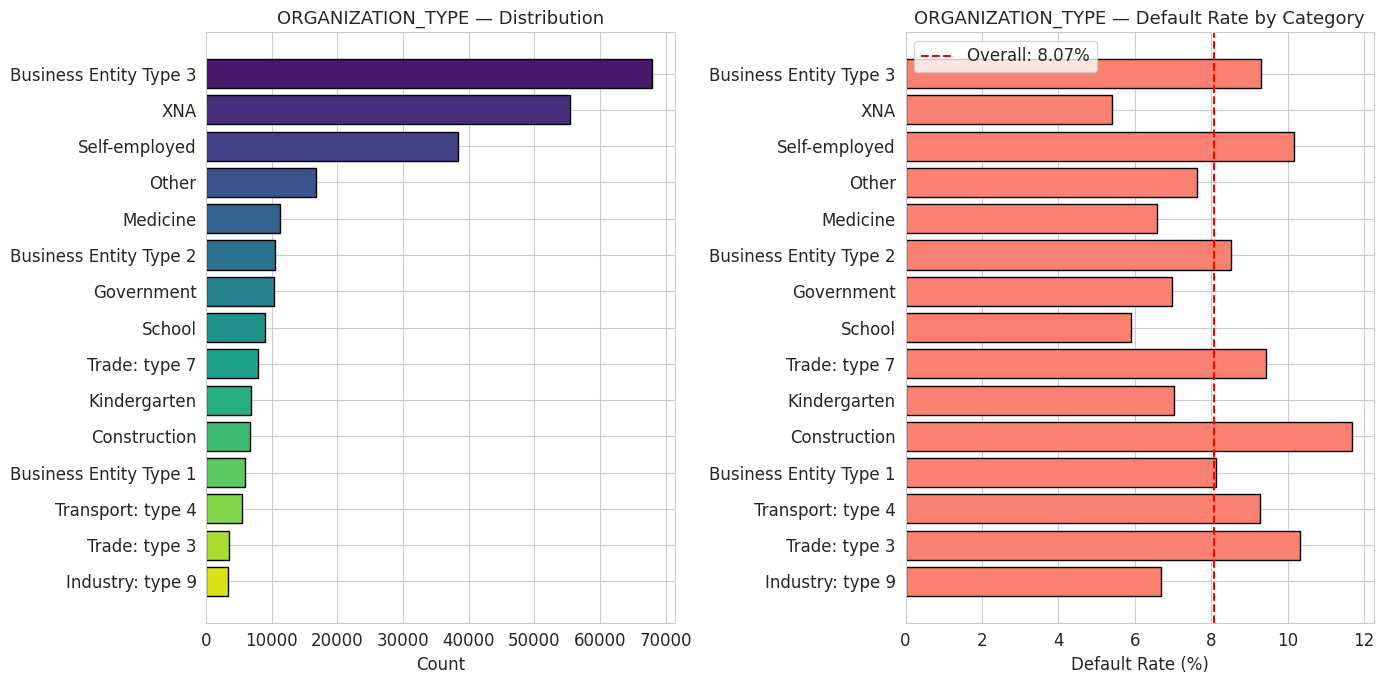

In [44]:
# Occupation Type & Organization Type (top 15)
plot_categorical(train, "OCCUPATION_TYPE", top_n=15, figsize=(14, 7))
plot_categorical(train, "ORGANIZATION_TYPE", top_n=15, figsize=(14, 7))

### Observations — Categorical Features
- **Cash loans** dominate (90.5%) and have a higher default rate (8.35%) than revolving loans (5.48%)
- **Males** default more (10.14%) than females (7.00%), though females take far more loans
- **Unemployed** and **Maternity leave** have extreme default rates (36-40%), but very small sample sizes
- **Lower secondary education** has the highest default rate (10.93%); academic degree holders the lowest (1.83%)
- **Rented apartment** residents default most (12.31%); house/apartment dwellers are the majority (88.7%)
- **Laborers** and **Drivers** have the highest default rates among major occupation categories

## 6. Univariate Analysis — Numerical Features

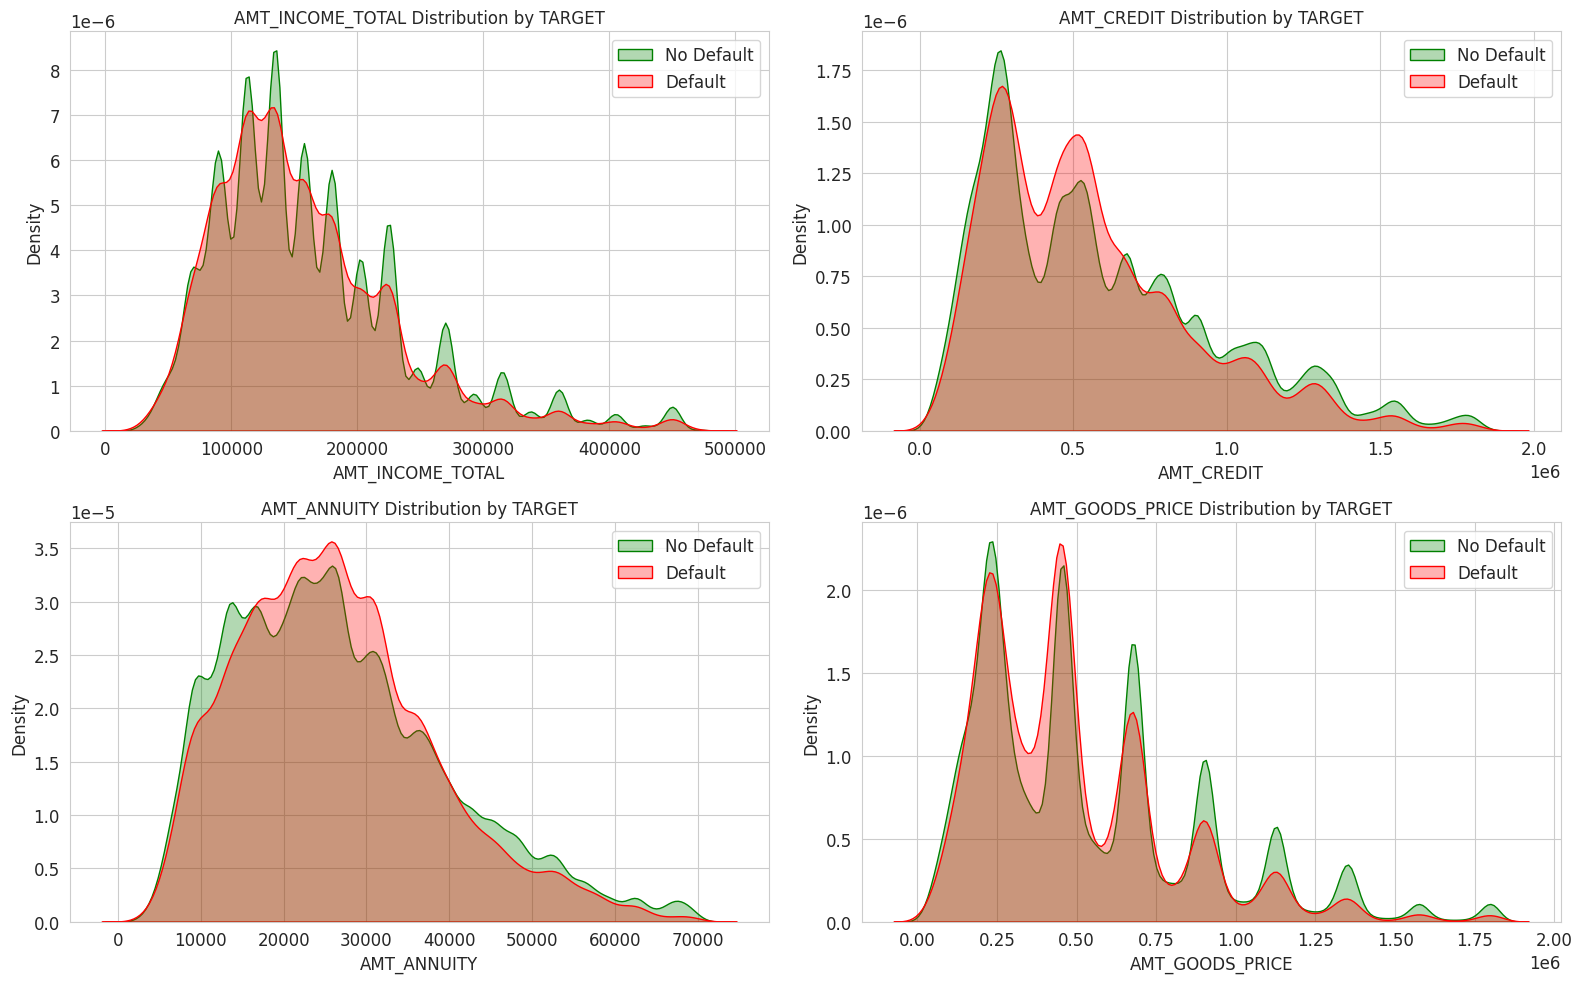

In [ ]:
# Distribution of financial features split by TARGET
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
financial_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]

for ax, col in zip(axes.flatten(), financial_cols):
    # Clip extreme outliers for better visualization
    cap = train[col].quantile(0.99)
    data_clipped = train[train[col] <= cap]

    sns.kdeplot(data=data_clipped[data_clipped["TARGET"]==0], x=col, ax=ax,
                label="No Default", color="green", fill=True, alpha=0.3)
    sns.kdeplot(data=data_clipped[data_clipped["TARGET"]==1], x=col, ax=ax,
                label="Default", color="red", fill=True, alpha=0.3)
    ax.set_title(f"{col} Distribution by TARGET", fontsize=12)
    ax.legend()

plt.tight_layout()
plt.show()

# this is KDI
# each value: how much 
# we can see left skewness
# tells that more amount of denisity of defualters are on left side - whose amount is less than
# the graps of 0 and 1 are overlayed

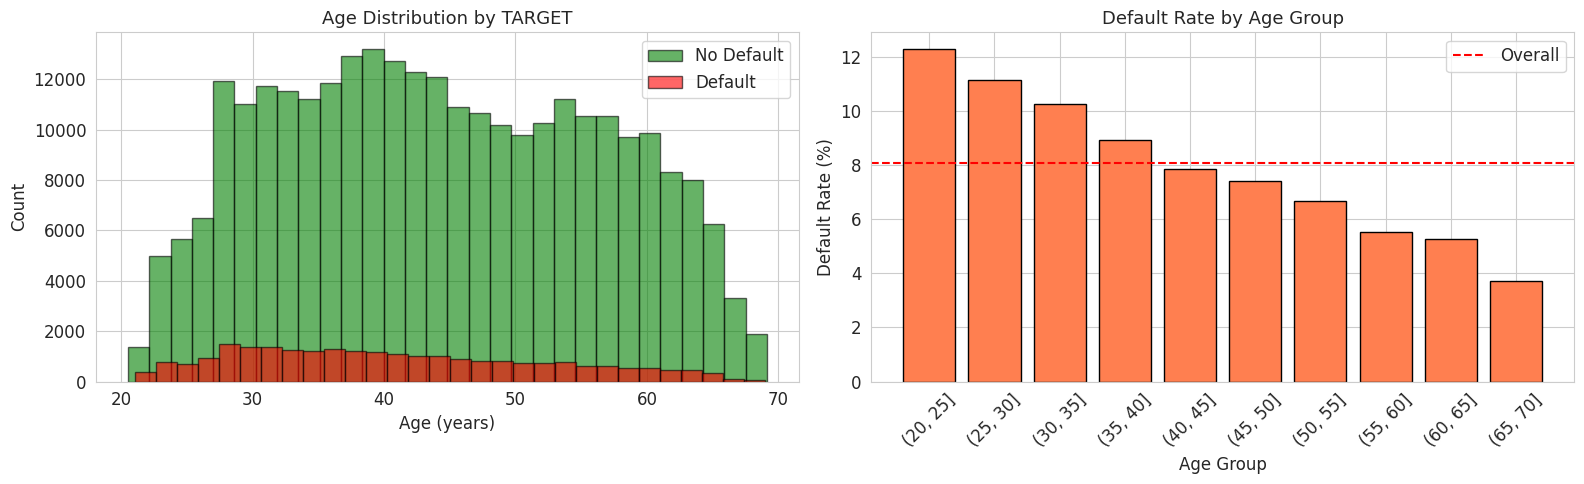

In [ ]:
# Age distribution (DAYS_BIRTH -> years)
train["AGE_YEARS"] = -train["DAYS_BIRTH"] / 365

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Age histogram by TARGET
axes[0].hist(train.loc[train["TARGET"]==0, "AGE_YEARS"], bins=30, alpha=0.6, color="green", label="No Default", edgecolor="black")
axes[0].hist(train.loc[train["TARGET"]==1, "AGE_YEARS"], bins=30, alpha=0.6, color="red", label="Default", edgecolor="black")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Count")
axes[0].set_title("Age Distribution by TARGET", fontsize=13)
axes[0].legend()

# Default rate by age bucket
train["AGE_BUCKET"] = pd.cut(train["AGE_YEARS"], bins=range(20, 75, 5))
age_default = train.groupby("AGE_BUCKET", observed=False)["TARGET"].mean() * 100
axes[1].bar(range(len(age_default)), age_default.values, color="coral", edgecolor="black")
axes[1].set_xticks(range(len(age_default)))
axes[1].set_xticklabels([str(x) for x in age_default.index], rotation=45)
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Default Rate (%)")
axes[1].set_title("Default Rate by Age Group", fontsize=13)
axes[1].axhline(y=train["TARGET"].mean()*100, color="red", linestyle="--", label="Overall")
axes[1].legend()

plt.tight_layout()
plt.show()

train.drop(columns=["AGE_YEARS", "AGE_BUCKET"], inplace=True)

#some age groups are more likely to default than others

DAYS_EMPLOYED anomalous values (365243 = ~1000 years): 55,374 (18.0%)


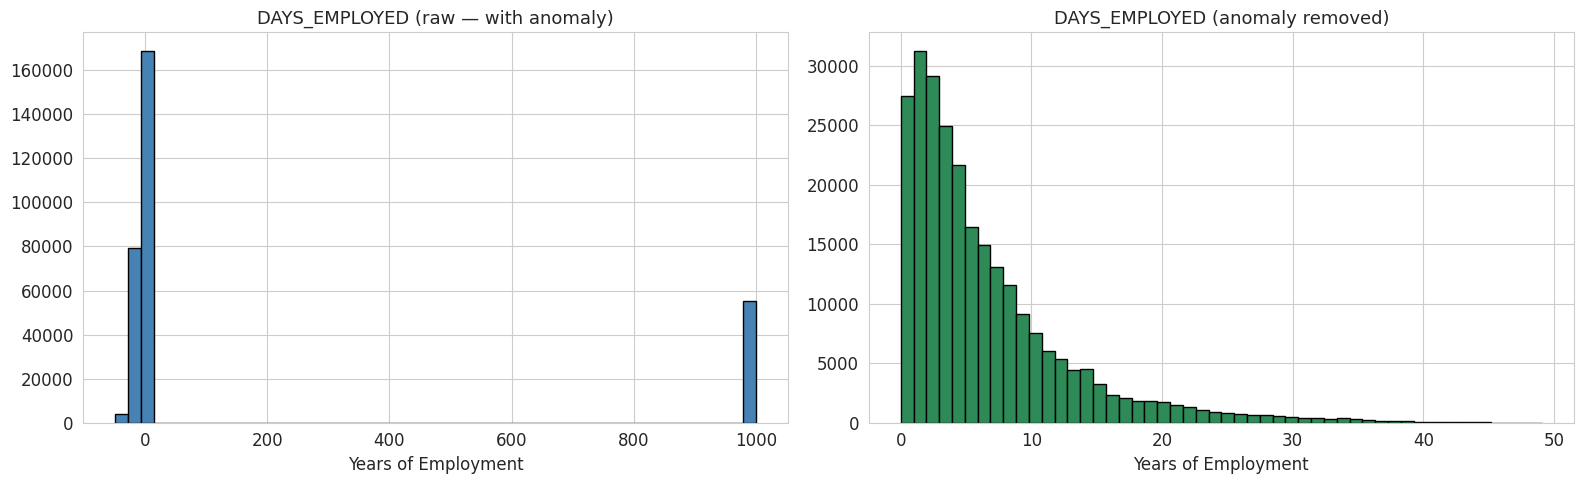


Default rate for anomalous (365243): 5.40%
Default rate for normal:             8.66%


In [47]:
# DAYS_EMPLOYED analysis — detect the 365243 anomaly
anomaly_count = (train["DAYS_EMPLOYED"] == 365243).sum()
print(f"DAYS_EMPLOYED anomalous values (365243 = ~1000 years): {anomaly_count:,} ({anomaly_count/len(train)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before fixing
axes[0].hist(train["DAYS_EMPLOYED"].values / 365, bins=50, color="steelblue", edgecolor="black")
axes[0].set_title("DAYS_EMPLOYED (raw — with anomaly)", fontsize=13)
axes[0].set_xlabel("Years of Employment")

# After removing anomaly
emp_clean = train.loc[train["DAYS_EMPLOYED"] != 365243, "DAYS_EMPLOYED"] / -365
axes[1].hist(emp_clean, bins=50, color="seagreen", edgecolor="black")
axes[1].set_title("DAYS_EMPLOYED (anomaly removed)", fontsize=13)
axes[1].set_xlabel("Years of Employment")

plt.tight_layout()
plt.show()

# Default rate: anomalous vs normal
anomaly_default = train.loc[train["DAYS_EMPLOYED"] == 365243, "TARGET"].mean()
normal_default = train.loc[train["DAYS_EMPLOYED"] != 365243, "TARGET"].mean()
print(f"\nDefault rate for anomalous (365243): {anomaly_default*100:.2f}%")
print(f"Default rate for normal:             {normal_default*100:.2f}%")

## 7. External Source Features (Most Predictive)

`EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3` are normalized scores from external data sources. These are the **most predictive features** in the dataset, with correlations of -0.155, -0.160, and -0.179 with TARGET respectively.

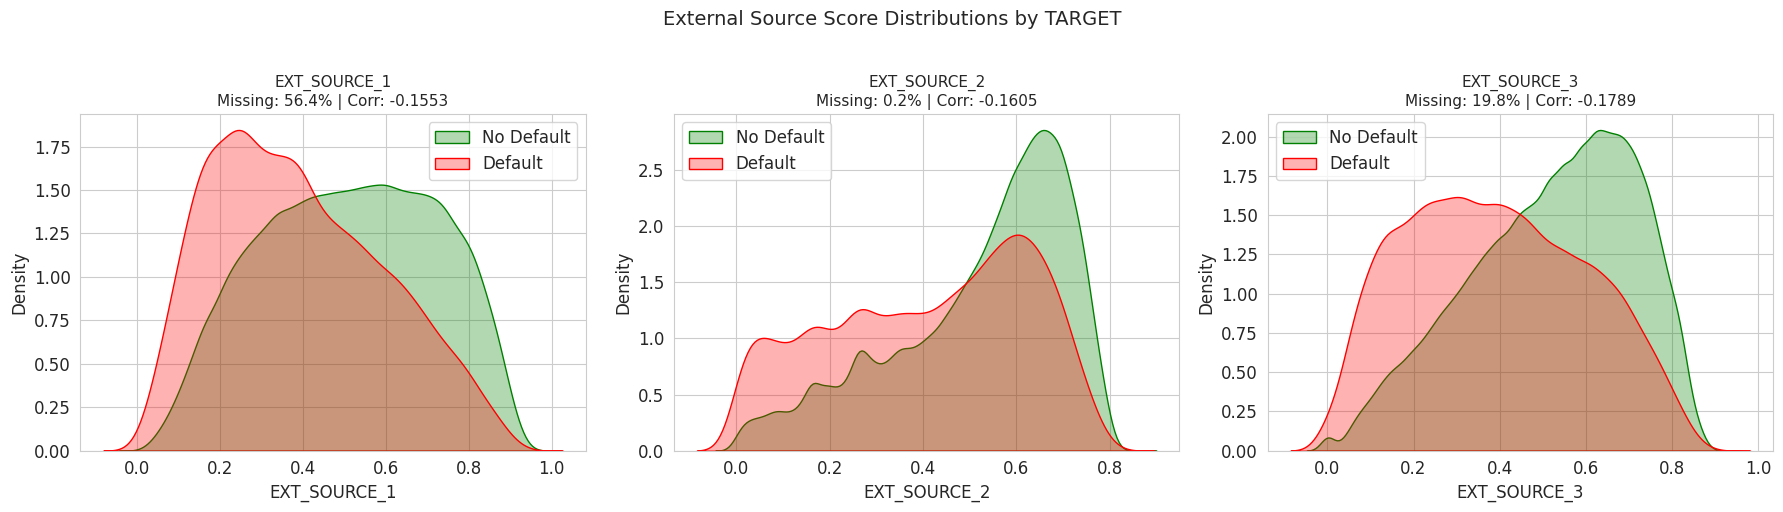

In [48]:
# EXT_SOURCE distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]):
    miss_pct = train[col].isnull().mean() * 100
    corr_val = train[col].corr(train["TARGET"])

    sns.kdeplot(data=train[train["TARGET"]==0], x=col, ax=ax, label="No Default", color="green", fill=True, alpha=0.3)
    sns.kdeplot(data=train[train["TARGET"]==1], x=col, ax=ax, label="Default", color="red", fill=True, alpha=0.3)
    ax.set_title(f"{col}\nMissing: {miss_pct:.1f}% | Corr: {corr_val:.4f}", fontsize=11)
    ax.legend()

plt.suptitle("External Source Score Distributions by TARGET", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Outlier Detection with Box Plots

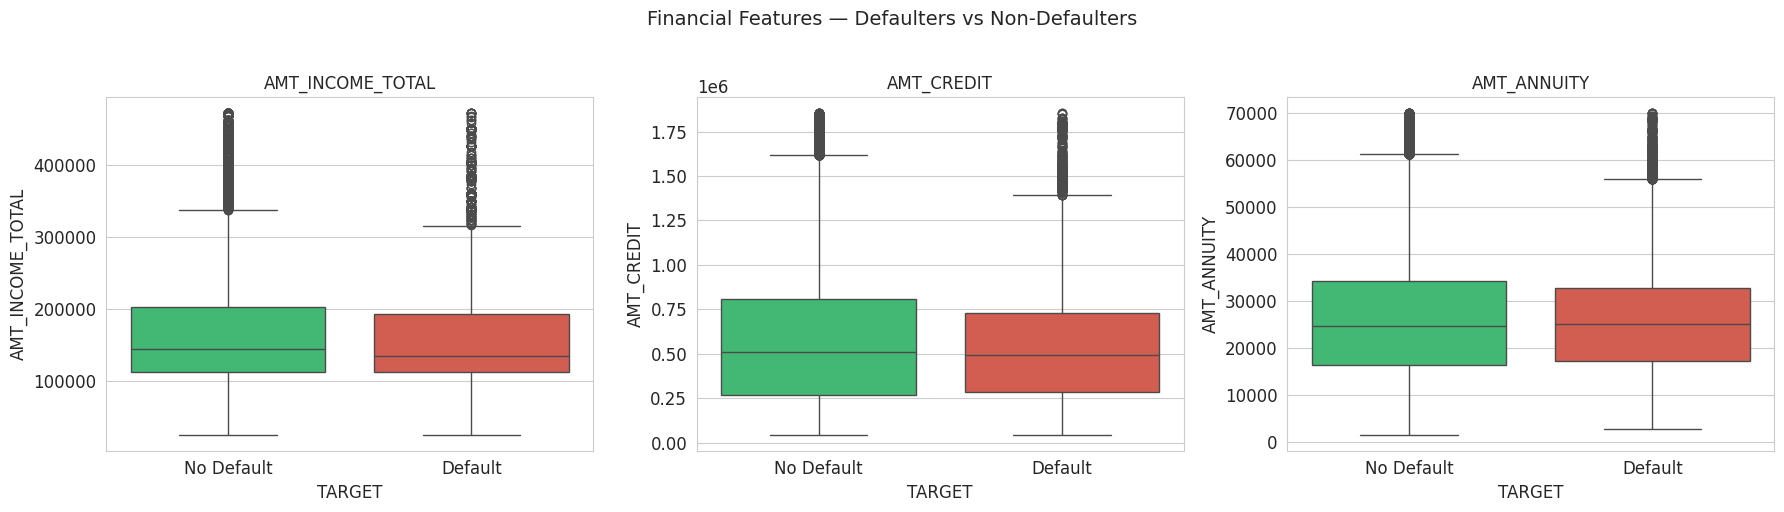

In [ ]:
# Box plots of financial features by TARGET
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
box_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]

for ax, col in zip(axes, box_cols):
    cap = train[col].quantile(0.99)
    data = train[train[col] <= cap]
    sns.boxplot(data=data, x="TARGET", y=col, ax=ax, palette=["#2ecc71", "#e74c3c"])
    ax.set_xticklabels(["No Default", "Default"])
    ax.set_title(f"{col}", fontsize=12)

plt.suptitle("Financial Features — Defaulters vs Non-Defaulters", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# box plots of outliers
# mostly neglible

## 9. Correlation Analysis

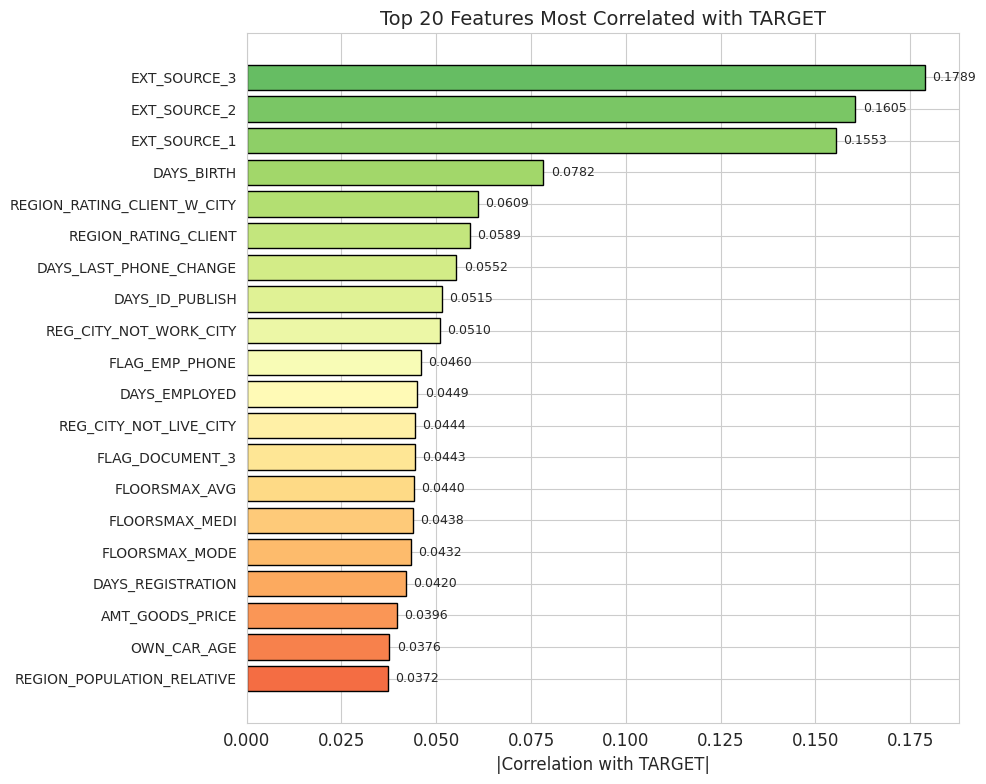

In [50]:
# Top 20 features correlated with TARGET
num_cols = train.select_dtypes(include=[np.number]).columns
correlations = train[num_cols].corrwith(train["TARGET"]).dropna().abs().sort_values(ascending=False)
top_corr = correlations.head(21)  # includes TARGET itself
top_corr = top_corr[top_corr.index != "TARGET"]

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(top_corr)))
ax.barh(range(len(top_corr)), top_corr.values, color=colors, edgecolor="black")
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index, fontsize=10)
ax.set_xlabel("|Correlation with TARGET|")
ax.set_title("Top 20 Features Most Correlated with TARGET", fontsize=14)
ax.invert_yaxis()

for i, v in enumerate(top_corr.values):
    ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

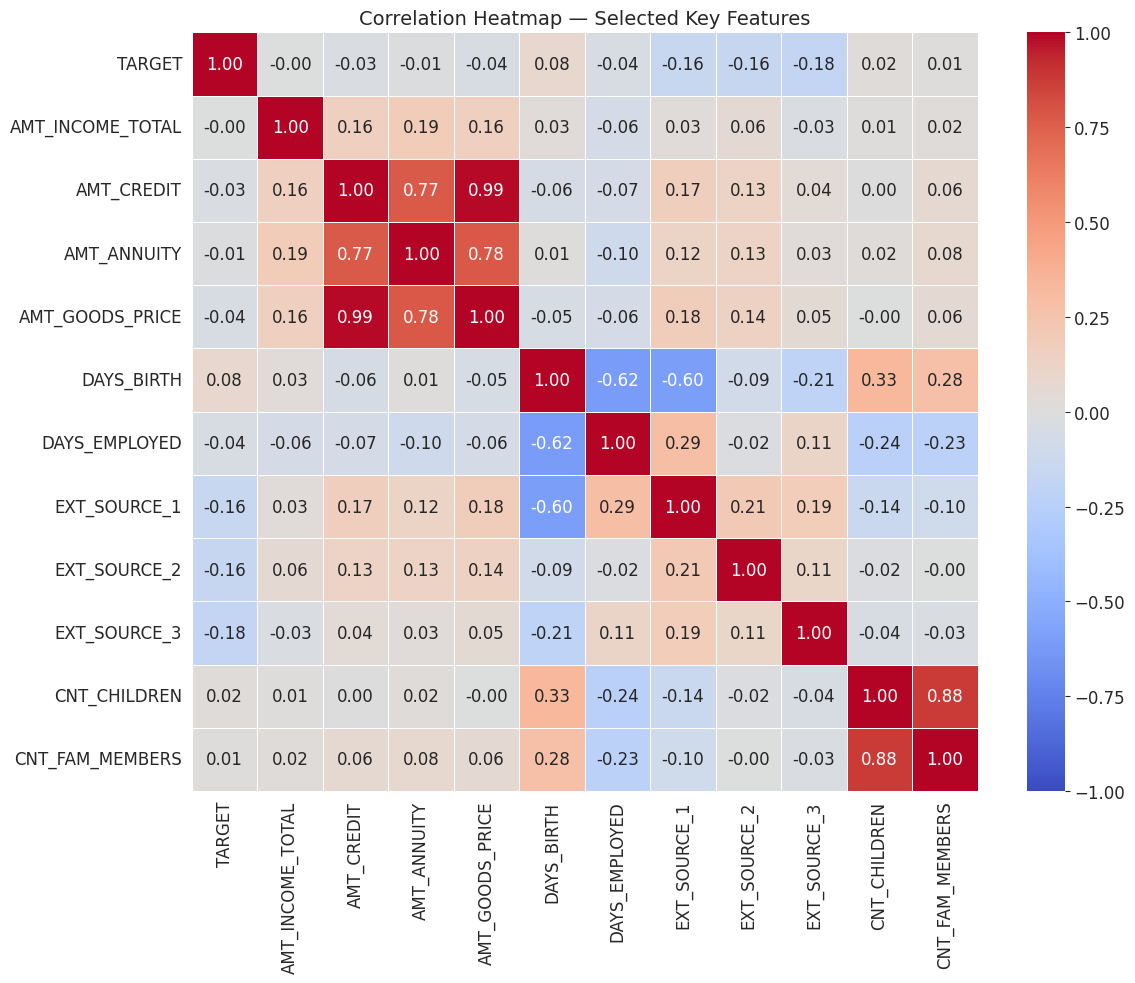

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define a set of relevant features for the heatmap
selected_features = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH", # Represents age
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

# Calculate the correlation matrix for the selected features
corr_matrix_selected = train[selected_features].corr()

# Plot the heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix_selected, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap — Selected Key Features", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Bivariate Analysis — Scatter Plots

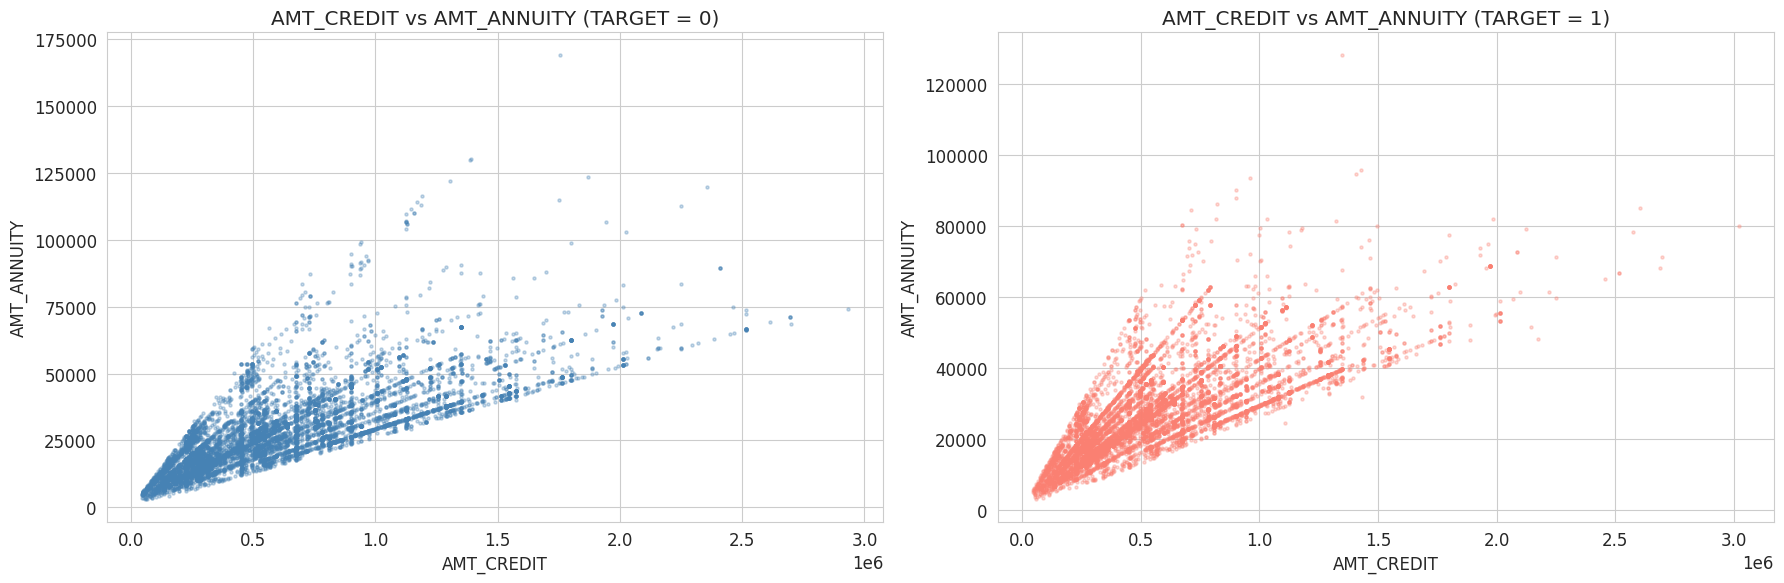

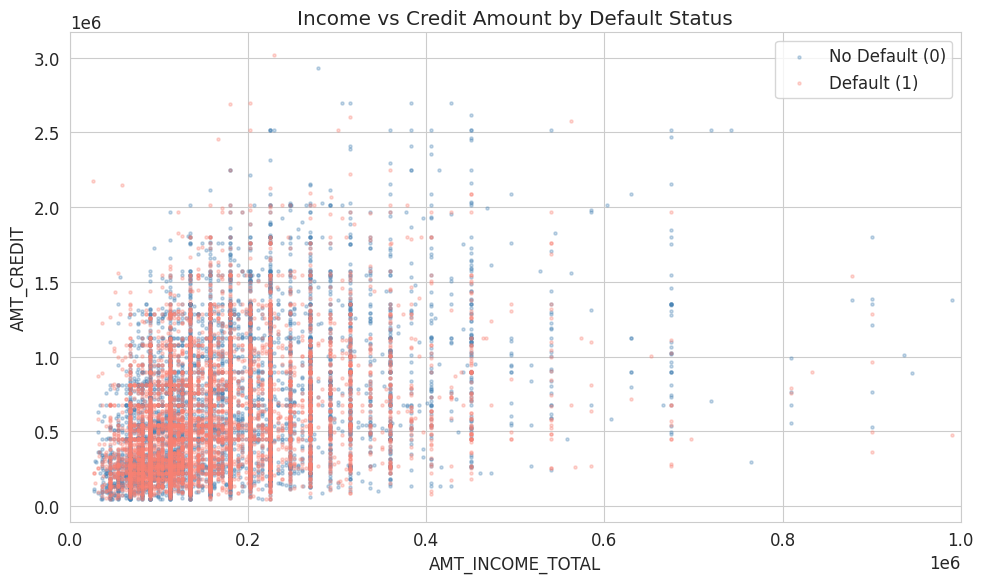

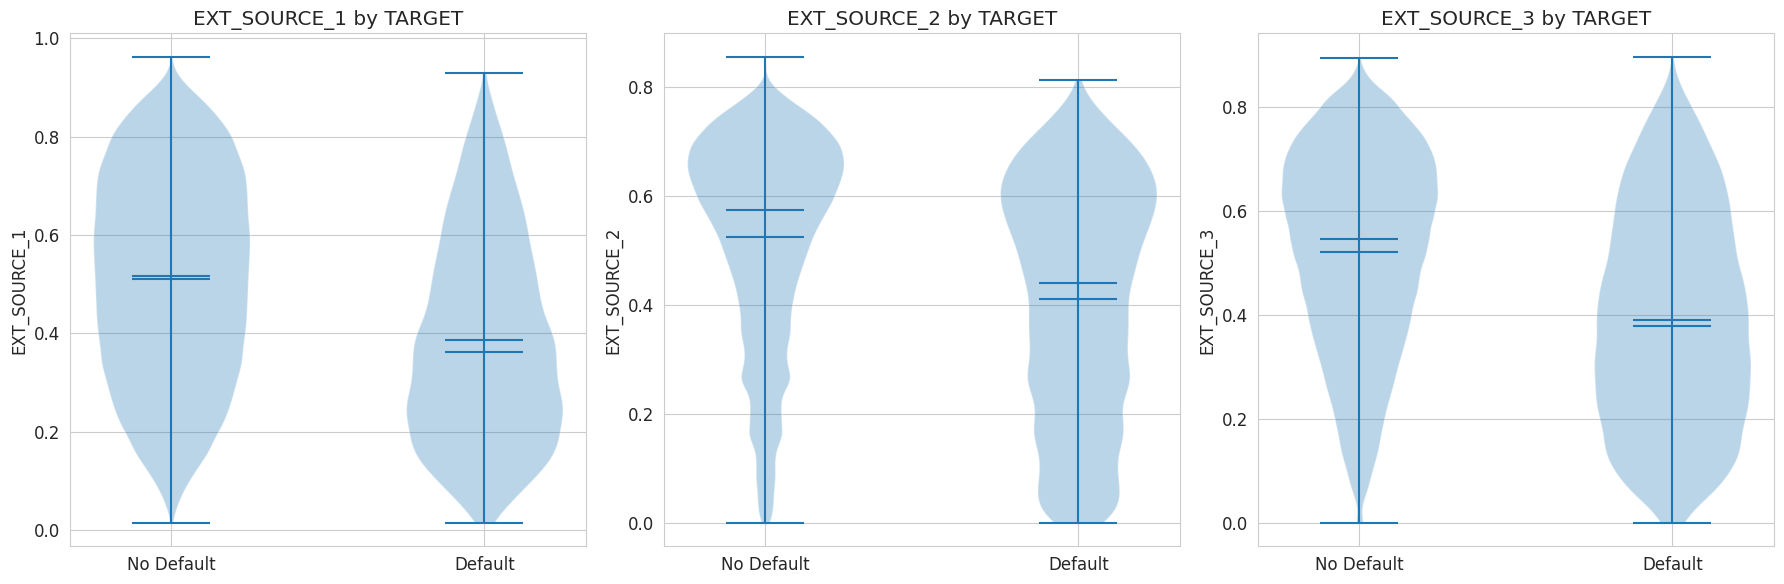

In [ ]:
# Scatter plot: AMT_CREDIT vs AMT_ANNUITY colored by TARGET
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for i, target_val in enumerate([0, 1]):
    subset = train[train['TARGET'] == target_val].sample(n=min(10000, (train['TARGET'] == target_val).sum()), random_state=42)
    axes[i].scatter(subset['AMT_CREDIT'], subset['AMT_ANNUITY'], alpha=0.3, s=5,
                    color='steelblue' if target_val == 0 else 'salmon')
    axes[i].set_xlabel('AMT_CREDIT')
    axes[i].set_ylabel('AMT_ANNUITY')
    axes[i].set_title(f'AMT_CREDIT vs AMT_ANNUITY (TARGET = {target_val})')

plt.tight_layout()
plt.show()

# Scatter plot: AMT_INCOME_TOTAL vs AMT_CREDIT colored by TARGET
fig, ax = plt.subplots(figsize=(10, 6))
sample_0 = train[train['TARGET'] == 0].sample(n=10000, random_state=42)
sample_1 = train[train['TARGET'] == 1].sample(n=min(10000, (train['TARGET'] == 1).sum()), random_state=42)
ax.scatter(sample_0['AMT_INCOME_TOTAL'], sample_0['AMT_CREDIT'], alpha=0.3, s=5,
           color='steelblue', label='No Default (0)')
ax.scatter(sample_1['AMT_INCOME_TOTAL'], sample_1['AMT_CREDIT'], alpha=0.3, s=5,
           color='salmon', label='Default (1)')
ax.set_xlabel('AMT_INCOME_TOTAL')
ax.set_ylabel('AMT_CREDIT')
ax.set_title('Income vs Credit Amount by Default Status')
ax.set_xlim(0, 1_000_000)
ax.legend()
plt.tight_layout()
plt.show()

# EXT_SOURCE features vs TARGET — violin plots
ext_cols = [c for c in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'] if c in train.columns]
if ext_cols:
    fig, axes = plt.subplots(1, len(ext_cols), figsize=(6 * len(ext_cols), 6))
    if len(ext_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, ext_cols):
        data_plot = train[[col, 'TARGET']].dropna()
        parts = ax.violinplot(
            [data_plot[data_plot['TARGET'] == t][col].values for t in [0, 1]],
            positions=[0, 1], showmeans=True, showmedians=True
        )
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['No Default', 'Default'])
        ax.set_title(f'{col} by TARGET')
        ax.set_ylabel(col)
    plt.tight_layout()
    plt.show()
    
    
# 3rds graph: we can see that higher values mean non defaulters and lower values mean defaulters

## 11. Bureau Data Analysis

The **bureau.csv** file contains information about clients' previous credits from other financial institutions, as reported to the Credit Bureau. Each row represents one credit per client.

In [53]:
# Load bureau data
bureau = pd.read_csv(os.path.join(DATA_DIR, 'bureau.csv'))
print(f"Bureau shape: {bureau.shape}")
print(f"\nColumn types:\n{bureau.dtypes}")
print(f"\nMissing values (top 10):")
missing_bureau = bureau.isnull().sum()
print(missing_bureau[missing_bureau > 0].sort_values(ascending=False).head(10))
bureau.head()

Bureau shape: (1716428, 17)

Column types:
SK_ID_CURR                  int64
SK_ID_BUREAU                int64
CREDIT_ACTIVE              object
CREDIT_CURRENCY            object
DAYS_CREDIT                 int64
CREDIT_DAY_OVERDUE          int64
DAYS_CREDIT_ENDDATE       float64
DAYS_ENDDATE_FACT         float64
AMT_CREDIT_MAX_OVERDUE    float64
CNT_CREDIT_PROLONG          int64
AMT_CREDIT_SUM            float64
AMT_CREDIT_SUM_DEBT       float64
AMT_CREDIT_SUM_LIMIT      float64
AMT_CREDIT_SUM_OVERDUE    float64
CREDIT_TYPE                object
DAYS_CREDIT_UPDATE          int64
AMT_ANNUITY               float64
dtype: object

Missing values (top 10):
AMT_ANNUITY               1226791
AMT_CREDIT_MAX_OVERDUE    1124488
DAYS_ENDDATE_FACT          633653
AMT_CREDIT_SUM_LIMIT       591780
AMT_CREDIT_SUM_DEBT        257669
DAYS_CREDIT_ENDDATE        105553
AMT_CREDIT_SUM                 13
dtype: int64


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


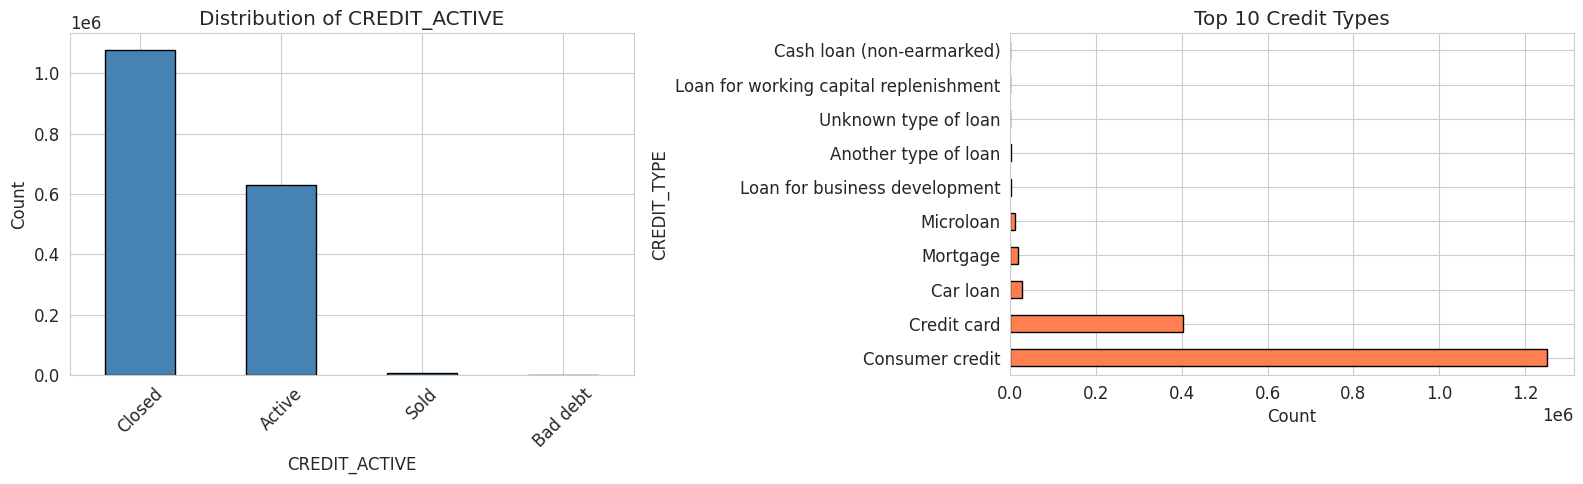


Credits per applicant — Mean: 5.6, Median: 4.0, Max: 116


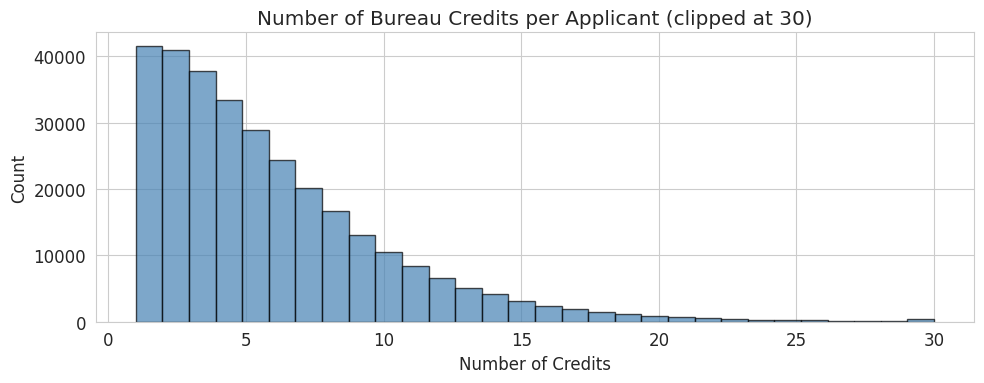

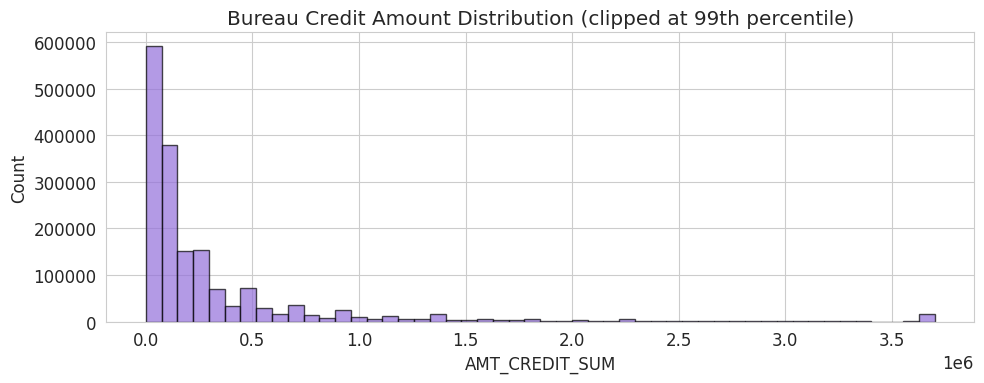

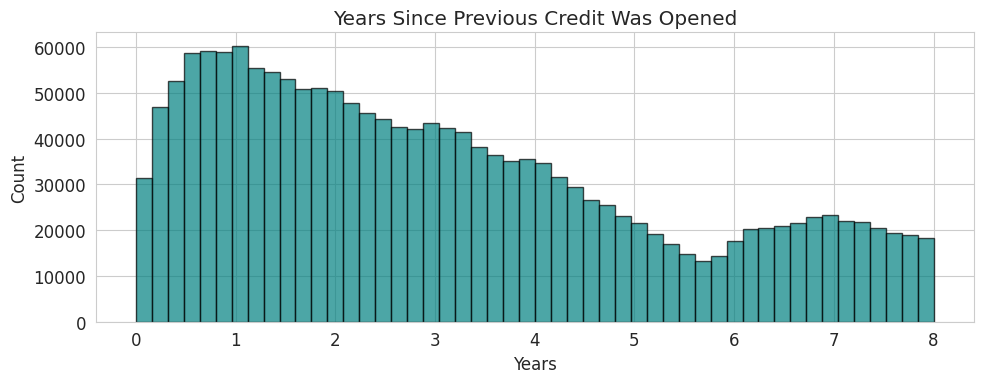


Clients with overdue credits: 3864 (1.3%)
Credits with overdue: 4217 (0.2%)

Bureau data cleaned from memory.


In [ ]:
# Bureau — Credit Active status distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bureau['CREDIT_ACTIVE'].value_counts().plot.bar(ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of CREDIT_ACTIVE')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Credit type distribution
bureau['CREDIT_TYPE'].value_counts().head(10).plot.barh(ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Top 10 Credit Types')
axes[1].set_xlabel('Count')
plt.tight_layout()
plt.show()

# Number of bureau credits per applicant
credits_per_app = bureau.groupby('SK_ID_CURR').size()
print(f"\nCredits per applicant — Mean: {credits_per_app.mean():.1f}, Median: {credits_per_app.median():.1f}, Max: {credits_per_app.max()}")

fig, ax = plt.subplots(figsize=(10, 4))
credits_per_app.clip(upper=30).hist(bins=30, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Number of Bureau Credits per Applicant (clipped at 30)')
ax.set_xlabel('Number of Credits')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Bureau credit amount distribution
fig, ax = plt.subplots(figsize=(10, 4))
bureau['AMT_CREDIT_SUM'].dropna().clip(upper=bureau['AMT_CREDIT_SUM'].quantile(0.99)).hist(
    bins=50, ax=ax, color='mediumpurple', edgecolor='black', alpha=0.7)
ax.set_title('Bureau Credit Amount Distribution (clipped at 99th percentile)')
ax.set_xlabel('AMT_CREDIT_SUM')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Days credit — how long ago were previous credits opened
fig, ax = plt.subplots(figsize=(10, 4))
(bureau['DAYS_CREDIT'] / -365).dropna().hist(bins=50, ax=ax, color='teal', edgecolor='black', alpha=0.7)
ax.set_title('Years Since Previous Credit Was Opened')
ax.set_xlabel('Years')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Overdue analysis
overdue = bureau[bureau['CREDIT_DAY_OVERDUE'] > 0]
print(f"\nClients with overdue credits: {overdue['SK_ID_CURR'].nunique()} ({overdue['SK_ID_CURR'].nunique() / bureau['SK_ID_CURR'].nunique() * 100:.1f}%)")
print(f"Credits with overdue: {len(overdue)} ({len(overdue) / len(bureau) * 100:.1f}%)")

del bureau
gc.collect()
print("\nBureau data cleaned from memory.")

# dsitribution of credit active ppl

# we can see decrease ands spike as years pass by

## 12. Previous Application Analysis

The **previous_application.csv** file contains data about previous loan applications made by clients in the main application dataset. Each row represents one previous application.

Uptil here, bureu and this one are external datasets

In [55]:
# Load previous application data
prev_app = pd.read_csv(os.path.join(DATA_DIR, 'previous_application.csv'))
print(f"Previous Application shape: {prev_app.shape}")
print(f"\nMissing values (top 10):")
missing_prev = prev_app.isnull().sum()
print(missing_prev[missing_prev > 0].sort_values(ascending=False).head(10))

# Replace 365243 anomaly with NaN (common sentinel value in this dataset)
prev_app['DAYS_FIRST_DRAWING'].replace(365243, np.nan, inplace=True)
prev_app['DAYS_FIRST_DUE'].replace(365243, np.nan, inplace=True)
prev_app['DAYS_LAST_DUE_1ST_VERSION'].replace(365243, np.nan, inplace=True)
prev_app['DAYS_LAST_DUE'].replace(365243, np.nan, inplace=True)
prev_app['DAYS_TERMINATION'].replace(365243, np.nan, inplace=True)
print("\nReplaced 365243 sentinel values with NaN in DAYS_* columns.")
prev_app.head()

Previous Application shape: (1670214, 37)

Missing values (top 10):
RATE_INTEREST_PRIVILEGED     1664263
RATE_INTEREST_PRIMARY        1664263
AMT_DOWN_PAYMENT              895844
RATE_DOWN_PAYMENT             895844
NAME_TYPE_SUITE               820405
DAYS_LAST_DUE                 673065
DAYS_FIRST_DRAWING            673065
DAYS_FIRST_DUE                673065
DAYS_TERMINATION              673065
NFLAG_INSURED_ON_APPROVAL     673065
dtype: int64

Replaced 365243 sentinel values with NaN in DAYS_* columns.


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,NaN,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,NaN,-134.0,916.0,NaN,NaN,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,NaN,-271.0,59.0,NaN,NaN,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,NaN,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


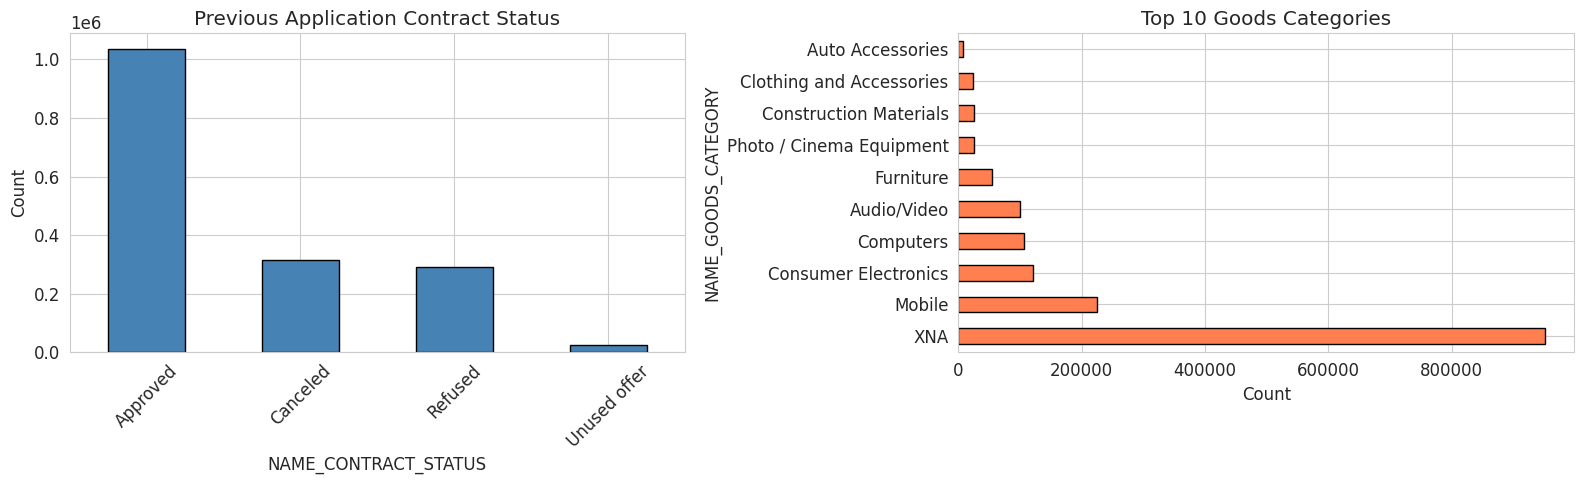


Previous applications per client — Mean: 4.9, Median: 4.0, Max: 77


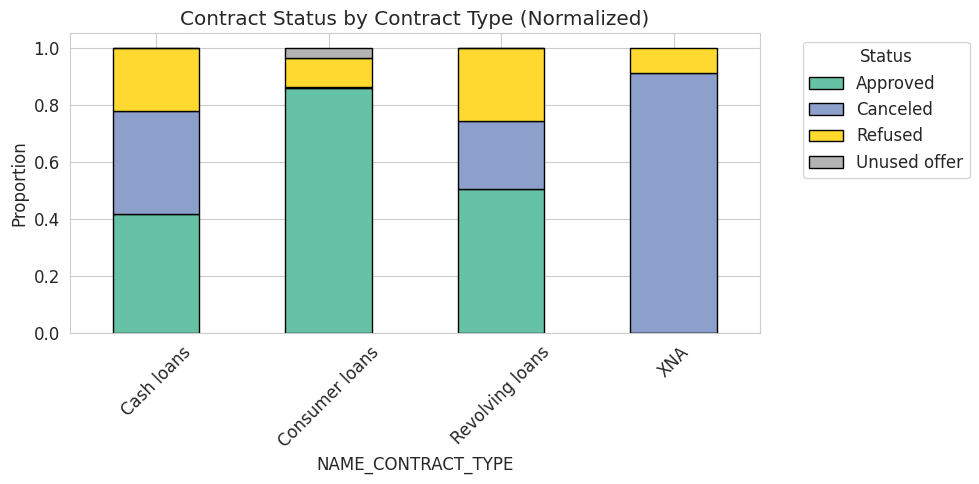

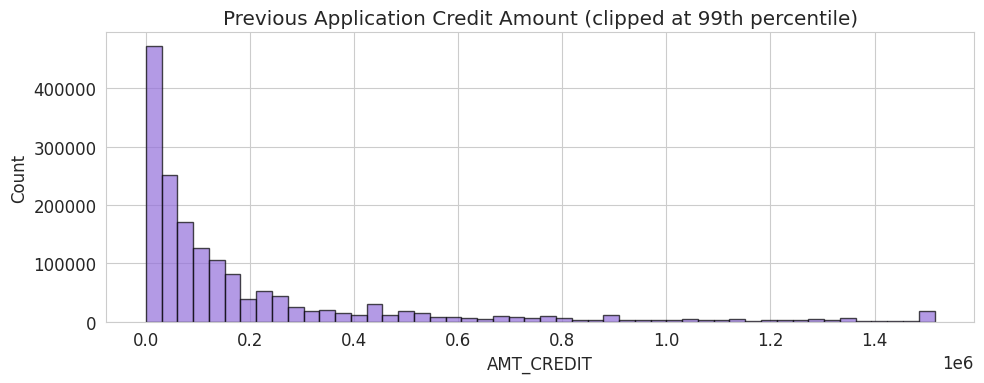


Previous application data cleaned from memory.


In [56]:
# Previous Application — Contract Status Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

prev_app['NAME_CONTRACT_STATUS'].value_counts().plot.bar(ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Previous Application Contract Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Previous application — Top goods categories
prev_app['NAME_GOODS_CATEGORY'].value_counts().head(10).plot.barh(ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Top 10 Goods Categories')
axes[1].set_xlabel('Count')
plt.tight_layout()
plt.show()

# Previous applications per client
prev_per_client = prev_app.groupby('SK_ID_CURR').size()
print(f"\nPrevious applications per client — Mean: {prev_per_client.mean():.1f}, Median: {prev_per_client.median():.1f}, Max: {prev_per_client.max()}")

# Approval rate by contract type
fig, ax = plt.subplots(figsize=(10, 5))
ct = pd.crosstab(prev_app['NAME_CONTRACT_TYPE'], prev_app['NAME_CONTRACT_STATUS'], normalize='index')
ct.plot.bar(stacked=True, ax=ax, colormap='Set2', edgecolor='black')
ax.set_title('Contract Status by Contract Type (Normalized)')
ax.set_ylabel('Proportion')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Credit amount in previous applications
fig, ax = plt.subplots(figsize=(10, 4))
prev_app['AMT_CREDIT'].dropna().clip(upper=prev_app['AMT_CREDIT'].quantile(0.99)).hist(
    bins=50, ax=ax, color='mediumpurple', edgecolor='black', alpha=0.7)
ax.set_title('Previous Application Credit Amount (clipped at 99th percentile)')
ax.set_xlabel('AMT_CREDIT')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

del prev_app
gc.collect()
print("\nPrevious application data cleaned from memory.")

## 13. POS Cash Balance Analysis

The **POS_CASH_balance.csv** file contains monthly data about previous point-of-sale or cash loans that clients had with Home Credit. It tracks the status and remaining balance over time.

This is an INTERNAL dataset

POS Cash Balance shape: (10001358, 8)
Unique clients: 337252
Unique previous loans: 936325

Records with DPD > 0: 295227 (2.95%)
Clients with any DPD: 62984 (18.7%)


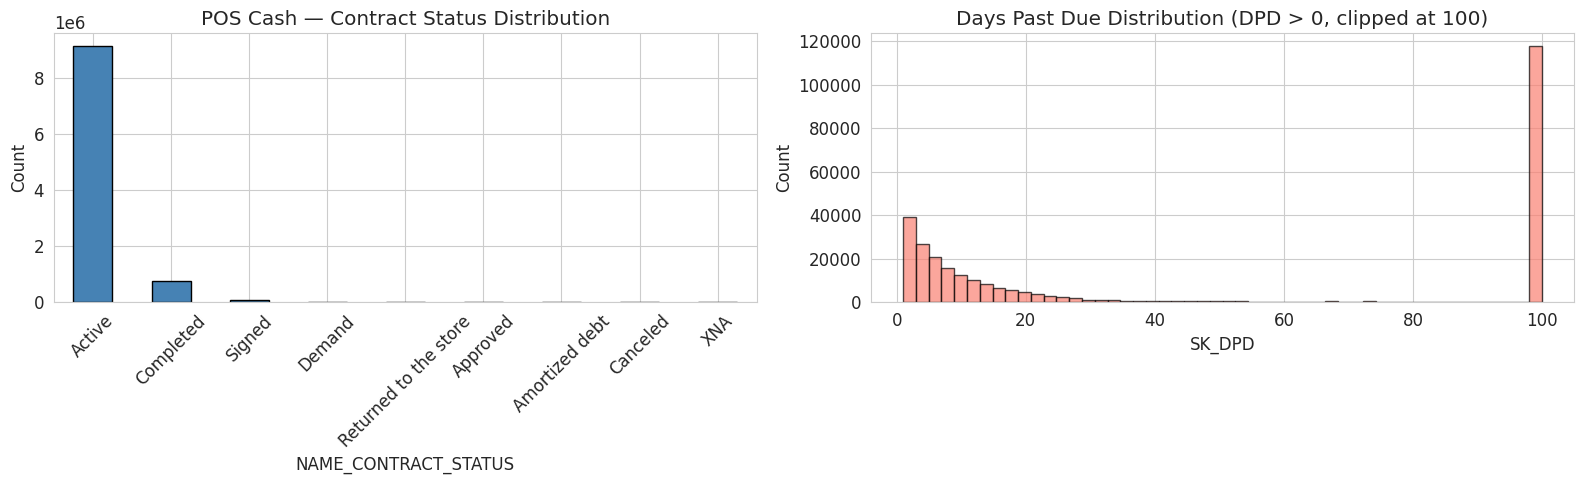

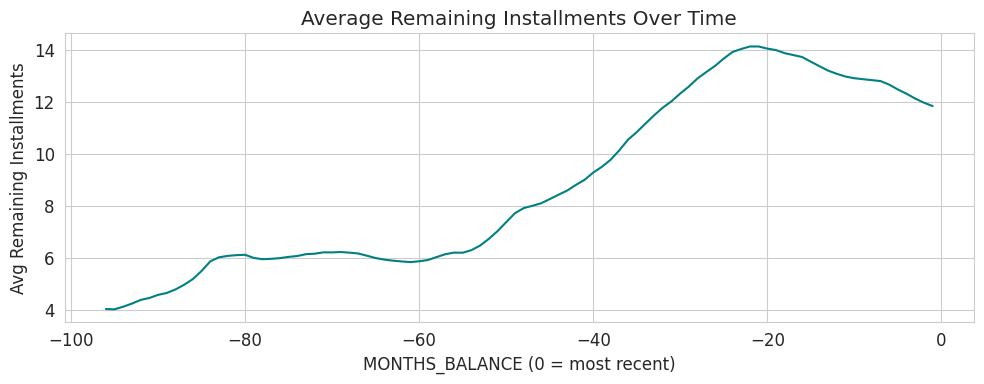


POS Cash balance data cleaned from memory.


In [ ]:
# Load POS Cash Balance data
pos = pd.read_csv(os.path.join(DATA_DIR, 'POS_CASH_balance.csv'))
print(f"POS Cash Balance shape: {pos.shape}")
print(f"Unique clients: {pos['SK_ID_CURR'].nunique()}")
print(f"Unique previous loans: {pos['SK_ID_PREV'].nunique()}")

# Contract status distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pos['NAME_CONTRACT_STATUS'].value_counts().plot.bar(ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('POS Cash — Contract Status Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Days Past Due (DPD) analysis
dpd_nonzero = pos[pos['SK_DPD'] > 0]
print(f"\nRecords with DPD > 0: {len(dpd_nonzero)} ({len(dpd_nonzero) / len(pos) * 100:.2f}%)")
print(f"Clients with any DPD: {dpd_nonzero['SK_ID_CURR'].nunique()} ({dpd_nonzero['SK_ID_CURR'].nunique() / pos['SK_ID_CURR'].nunique() * 100:.1f}%)")

dpd_nonzero['SK_DPD'].clip(upper=100).hist(bins=50, ax=axes[1], color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_title('Days Past Due Distribution (DPD > 0, clipped at 100)')
axes[1].set_xlabel('SK_DPD')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

# Monthly installments remaining over time
fig, ax = plt.subplots(figsize=(10, 4))
monthly_avg = pos.groupby('MONTHS_BALANCE')['CNT_INSTALMENT_FUTURE'].mean()
monthly_avg.plot(ax=ax, color='teal', linewidth=1.5)
ax.set_title('Average Remaining Installments Over Time')
ax.set_xlabel('MONTHS_BALANCE (0 = most recent)')
ax.set_ylabel('Avg Remaining Installments')
plt.tight_layout()
plt.show()

del pos
gc.collect()
print("\nPOS Cash balance data cleaned from memory.")


# DPD - delta 30,60,90 etc
# number of installments decrease as we have more number of -ve days remaining

## 14. Credit Card Balance Analysis

The **credit_card_balance.csv** file contains monthly snapshots of credit card balances for previous credit cards that clients had with Home Credit.

Credit Card Balance shape: (3840312, 23)
Unique clients: 103558
Unique previous loans: 104307


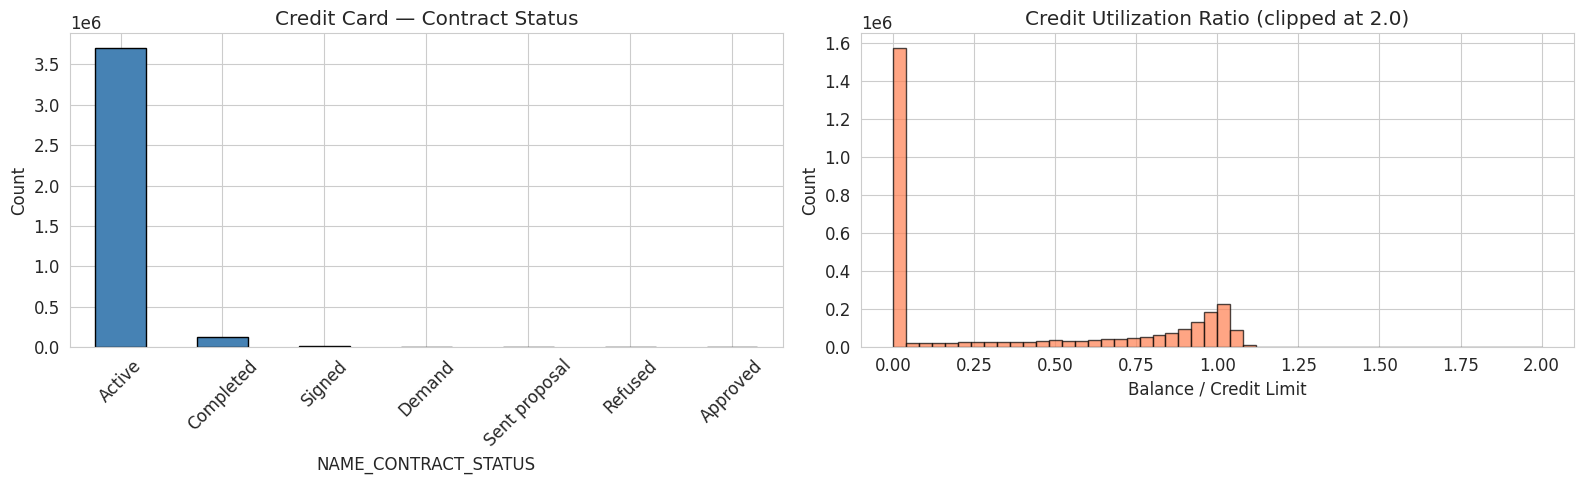

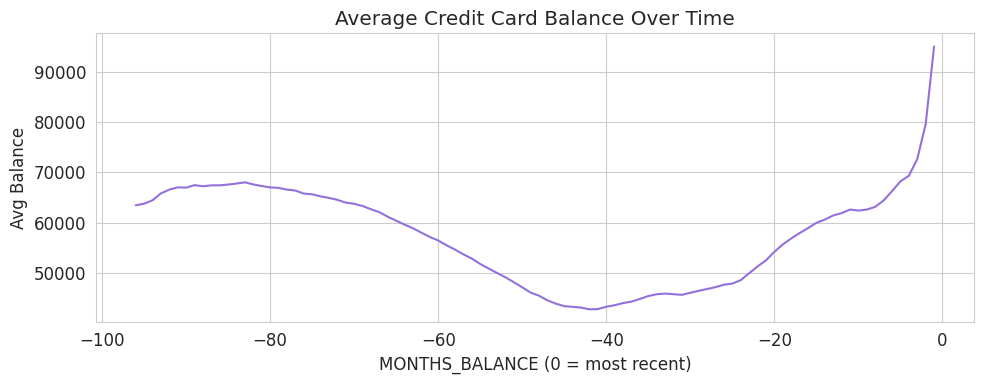


Records with DPD > 0: 153355 (3.99%)
Clients with any CC DPD: 20660 (20.0%)

Credit card balance data cleaned from memory.


In [ ]:
# Load Credit Card Balance data
cc = pd.read_csv(os.path.join(DATA_DIR, 'credit_card_balance.csv'))
print(f"Credit Card Balance shape: {cc.shape}")
print(f"Unique clients: {cc['SK_ID_CURR'].nunique()}")
print(f"Unique previous loans: {cc['SK_ID_PREV'].nunique()}")

# Contract status
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cc['NAME_CONTRACT_STATUS'].value_counts().plot.bar(ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Credit Card — Contract Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Credit utilization ratio
cc['UTILIZATION'] = cc['AMT_BALANCE'] / cc['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
cc['UTILIZATION'].dropna().clip(0, 2).hist(bins=50, ax=axes[1], color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Credit Utilization Ratio (clipped at 2.0)')
axes[1].set_xlabel('Balance / Credit Limit')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

# Average balance over time
fig, ax = plt.subplots(figsize=(10, 4))
monthly_bal = cc.groupby('MONTHS_BALANCE')['AMT_BALANCE'].mean()
monthly_bal.plot(ax=ax, color='mediumpurple', linewidth=1.5)
ax.set_title('Average Credit Card Balance Over Time')
ax.set_xlabel('MONTHS_BALANCE (0 = most recent)')
ax.set_ylabel('Avg Balance')
plt.tight_layout()
plt.show()

# DPD analysis
dpd_cc = cc[cc['SK_DPD'] > 0]
print(f"\nRecords with DPD > 0: {len(dpd_cc)} ({len(dpd_cc) / len(cc) * 100:.2f}%)")
print(f"Clients with any CC DPD: {dpd_cc['SK_ID_CURR'].nunique()} ({dpd_cc['SK_ID_CURR'].nunique() / cc['SK_ID_CURR'].nunique() * 100:.1f}%)")

del cc
gc.collect()
print("\nCredit card balance data cleaned from memory.")

# x axis is dpd (days)
#we cn see that after 40, the outstanding balance tends to be higher

## 15. Installments Payments Analysis

The **installments_payments.csv** file contains the payment history for previous loans. Each row represents one payment made (or expected) on a previous loan installment.

Installments Payments shape: (13605401, 8)
Unique clients: 339587
Unique previous loans: 997752


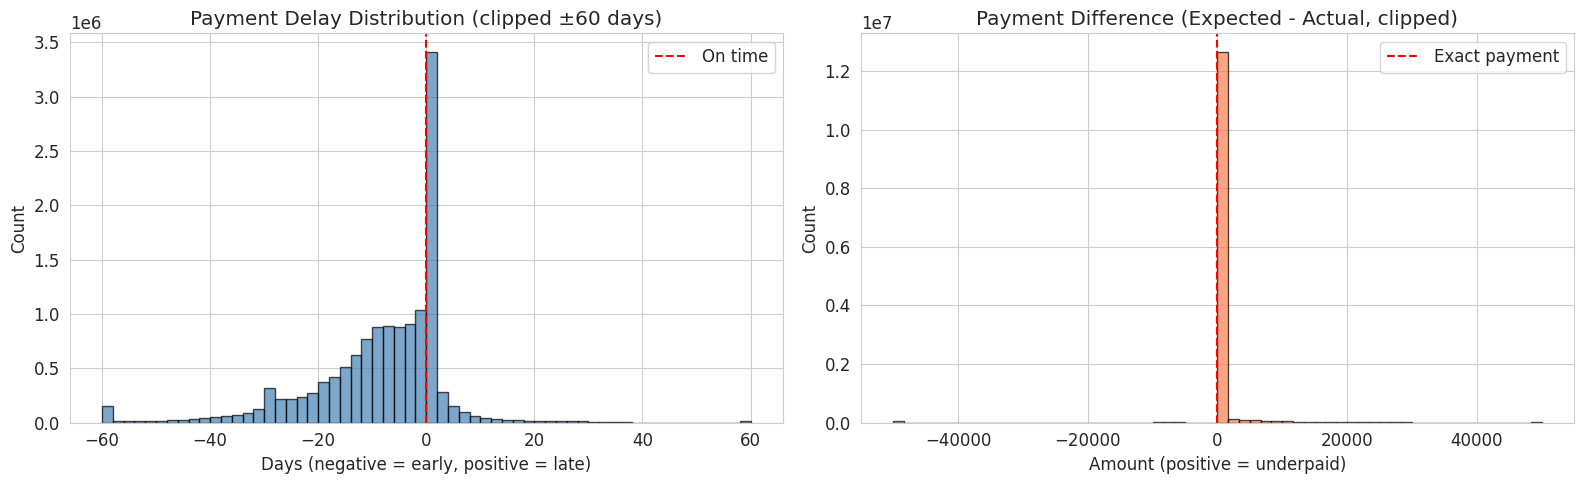


Late payments: 1146669 (8.4%)
Underpaid installments: 1295493 (9.5%)
Clients with any late payment: 179845 (53.0%)


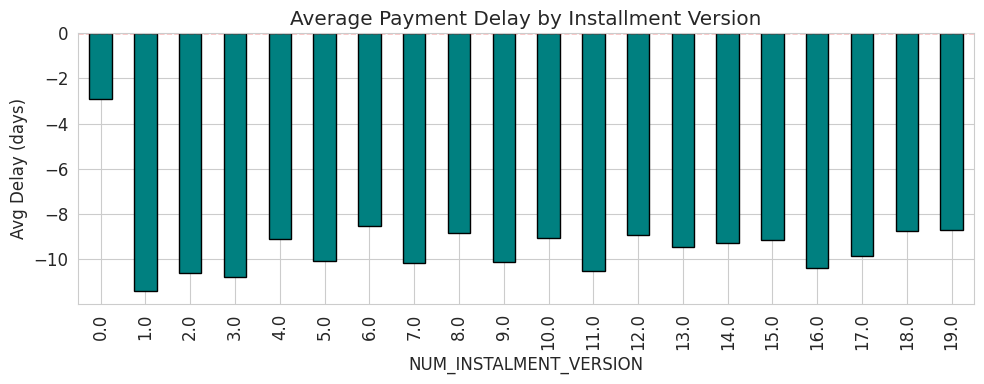


Installments payments data cleaned from memory.


In [59]:
# Load Installments Payments data
inst = pd.read_csv(os.path.join(DATA_DIR, 'installments_payments.csv'))
print(f"Installments Payments shape: {inst.shape}")
print(f"Unique clients: {inst['SK_ID_CURR'].nunique()}")
print(f"Unique previous loans: {inst['SK_ID_PREV'].nunique()}")

# Payment timeliness: DAYS_INSTALMENT - DAYS_ENTRY_PAYMENT
# Negative = paid early, Positive = paid late
inst['PAYMENT_DELAY'] = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']
inst['PAYMENT_DIFF'] = inst['AMT_INSTALMENT'] - inst['AMT_PAYMENT']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Payment delay distribution
inst['PAYMENT_DELAY'].clip(-60, 60).dropna().hist(bins=60, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='On time')
axes[0].set_title('Payment Delay Distribution (clipped ±60 days)')
axes[0].set_xlabel('Days (negative = early, positive = late)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Payment difference distribution
inst['PAYMENT_DIFF'].clip(-50000, 50000).dropna().hist(bins=60, ax=axes[1], color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Exact payment')
axes[1].set_title('Payment Difference (Expected - Actual, clipped)')
axes[1].set_xlabel('Amount (positive = underpaid)')
axes[1].set_ylabel('Count')
axes[1].legend()
plt.tight_layout()
plt.show()

# Late payment statistics
late = inst[inst['PAYMENT_DELAY'] > 0]
underpaid = inst[inst['PAYMENT_DIFF'] > 0]
print(f"\nLate payments: {len(late)} ({len(late) / len(inst) * 100:.1f}%)")
print(f"Underpaid installments: {len(underpaid)} ({len(underpaid) / len(inst) * 100:.1f}%)")
print(f"Clients with any late payment: {late['SK_ID_CURR'].nunique()} ({late['SK_ID_CURR'].nunique() / inst['SK_ID_CURR'].nunique() * 100:.1f}%)")

# Average payment behavior by installment version number
fig, ax = plt.subplots(figsize=(10, 4))
ver_delay = inst.groupby('NUM_INSTALMENT_VERSION')['PAYMENT_DELAY'].mean().head(20)
ver_delay.plot.bar(ax=ax, color='teal', edgecolor='black')
ax.set_title('Average Payment Delay by Installment Version')
ax.set_xlabel('NUM_INSTALMENT_VERSION')
ax.set_ylabel('Avg Delay (days)')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

del inst
gc.collect()
print("\nInstallments payments data cleaned from memory.")

## 16. Feature Distribution — Skewness & Kurtosis

Examining the skewness and kurtosis of numerical features helps identify which columns need transformation (e.g., log, Box-Cox) before modeling.

Top 10 most positively skewed features:
                              Skewness      Kurtosis
FLAG_DOCUMENT_7             156.110538  24369.499836
FLAG_DOCUMENT_4              98.723857   9744.799787
OBS_30_CNT_SOCIAL_CIRCLE     57.638489   5550.429670
OBS_60_CNT_SOCIAL_CIRCLE     57.351580   5512.411530
FLAG_DOCUMENT_11             29.192662    850.246402
AMT_REQ_CREDIT_BUREAU_DAY    28.273838    897.696140
FLAG_DOCUMENT_18             25.266762    636.435387
AMT_REQ_CREDIT_BUREAU_HOUR   22.413085    519.751450
AMT_REQ_CREDIT_BUREAU_WEEK   20.182271    435.144522
DEF_30_CNT_SOCIAL_CIRCLE     20.003112   1164.902315

Top 10 most negatively skewed features:
                                Skewness      Kurtosis
YEARS_BUILD_AVG                -0.884198      4.252369
YEARS_BUILD_MEDI               -0.891927      4.358014
YEARS_BUILD_MODE               -0.933707      4.690093
FLAG_DOCUMENT_3                -1.399234     -0.042147
FLAG_EMP_PHONE                 -1.578153      0.490586
YEARS_

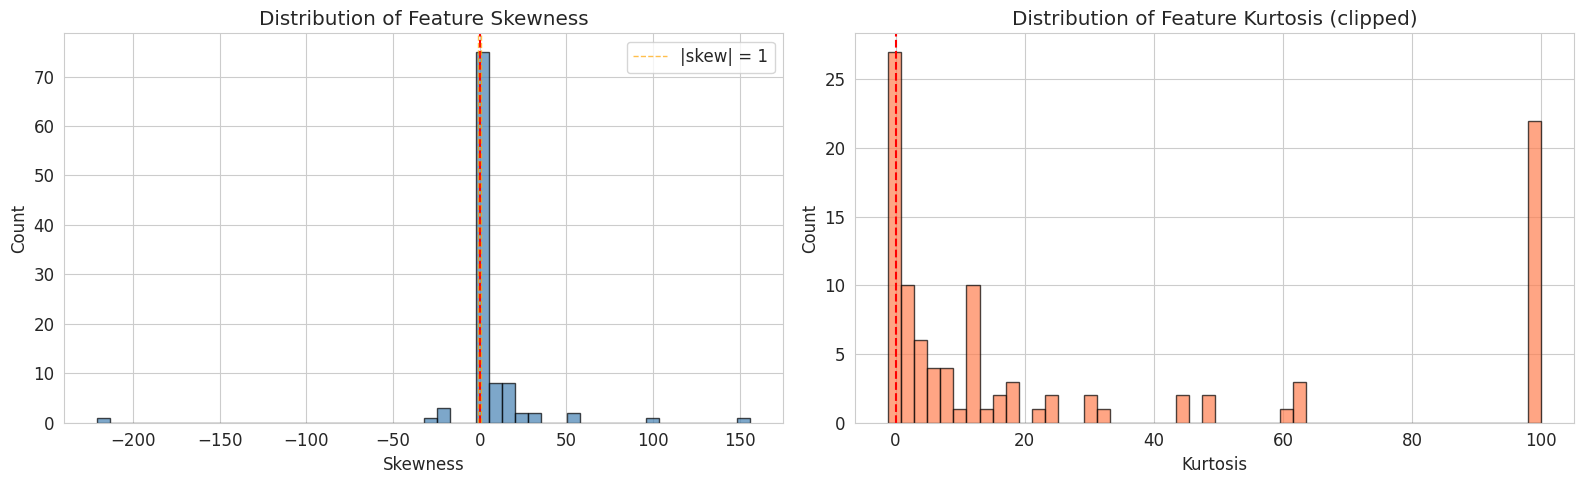


Features with |skewness| > 2: 59 out of 104 numerical features (56.7%)


In [60]:
# Compute skewness and kurtosis for numerical features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['SK_ID_CURR', 'TARGET']]

skew_kurt = pd.DataFrame({
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurtosis()
}).sort_values('Skewness', ascending=False)

print("Top 10 most positively skewed features:")
print(skew_kurt.head(10))
print(f"\nTop 10 most negatively skewed features:")
print(skew_kurt.tail(10))

# Visualize skewness distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

skew_kurt['Skewness'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].axvline(-1, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='|skew| = 1')
axes[0].axvline(1, color='orange', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_title('Distribution of Feature Skewness')
axes[0].set_xlabel('Skewness')
axes[0].set_ylabel('Count')
axes[0].legend()

skew_kurt['Kurtosis'].clip(-10, 100).hist(bins=50, ax=axes[1], color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribution of Feature Kurtosis (clipped)')
axes[1].set_xlabel('Kurtosis')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

# Highly skewed features that may need transformation
highly_skewed = skew_kurt[skew_kurt['Skewness'].abs() > 2]
print(f"\nFeatures with |skewness| > 2: {len(highly_skewed)} out of {len(num_cols)} numerical features ({len(highly_skewed)/len(num_cols)*100:.1f}%)")

## 17. Bureau Balance Analysis

The **bureau_balance.csv** file contains monthly status data for credits reported in the bureau. Each row represents one month of one bureau credit. STATUS values: 0 = on time, 1 = 1–30 DPD, 2 = 31–60 DPD, 3 = 61–90 DPD, 4 = 91–120 DPD, 5 = 121+ DPD or written off, C = closed, X = unknown.

Bureau Balance shape: (27299925, 3)
Unique bureau credits: 817395

STATUS value counts:
STATUS
C    13646993
0     7499507
X     5810482
1      242347
5       62406
2       23419
3        8924
4        5847
Name: count, dtype: int64


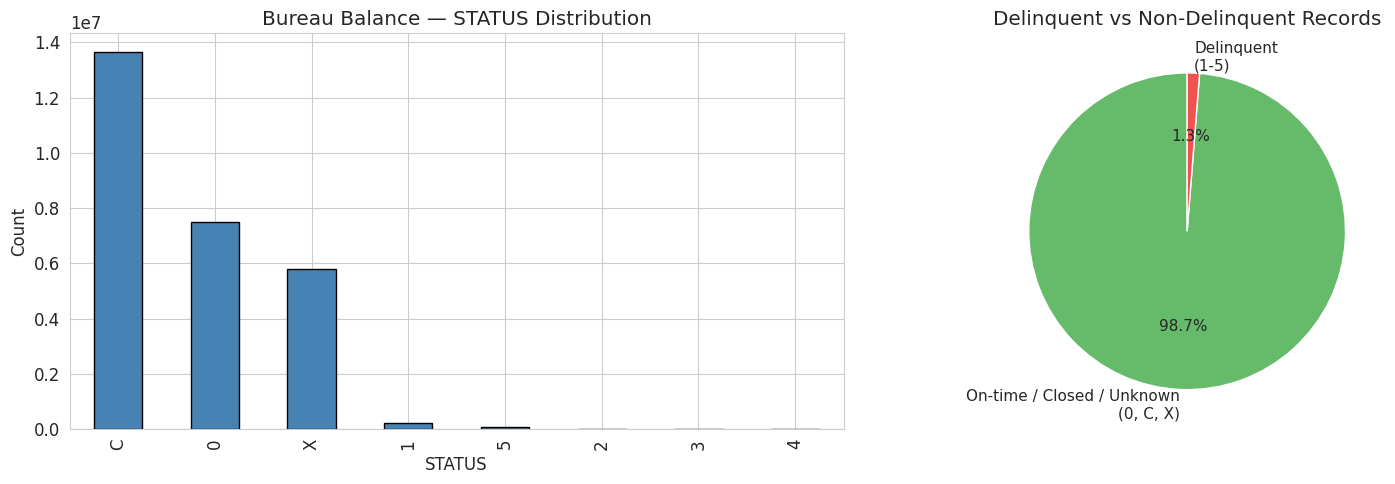


Months of history per credit — Mean: 33.4, Median: 26.0, Max: 97


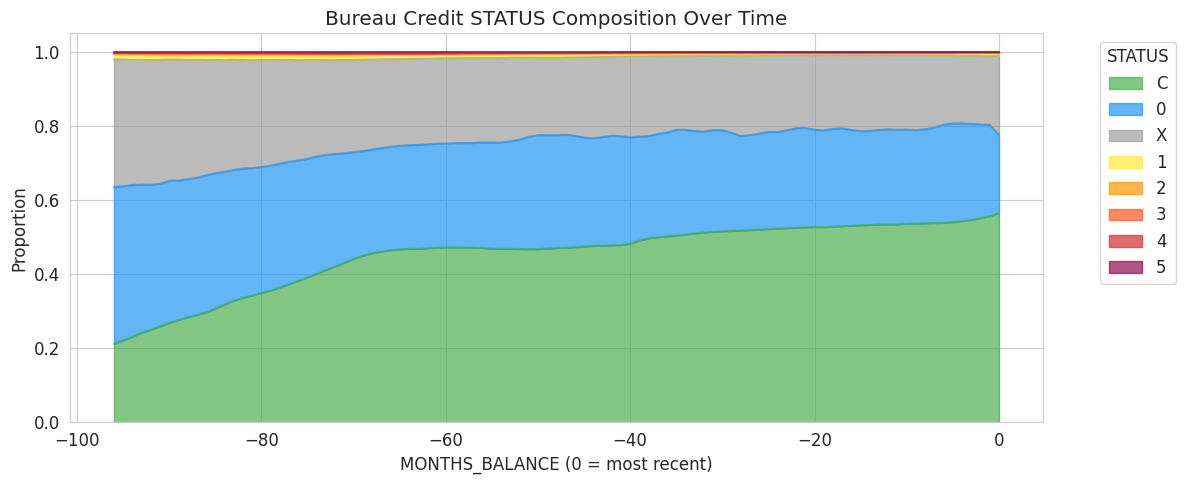


Bureau balance data cleaned from memory.


In [61]:
# Load Bureau Balance data (large file — ~27M rows)
bb = pd.read_csv(os.path.join(DATA_DIR, 'bureau_balance.csv'))
print(f"Bureau Balance shape: {bb.shape}")
print(f"Unique bureau credits: {bb['SK_ID_BUREAU'].nunique()}")
print(f"\nSTATUS value counts:")
status_counts = bb['STATUS'].value_counts()
print(status_counts)

# STATUS distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

status_counts.plot.bar(ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Bureau Balance — STATUS Distribution')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('STATUS')

# Proportion of delinquent statuses (1-5) vs on-time (0, C, X)
delinquent = bb['STATUS'].isin(['1', '2', '3', '4', '5']).sum()
total = len(bb)
labels = ['On-time / Closed / Unknown\n(0, C, X)', 'Delinquent\n(1-5)']
sizes = [total - delinquent, delinquent]
colors = ['#66bb6a', '#ef5350']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Delinquent vs Non-Delinquent Records')
plt.tight_layout()
plt.show()

# Average months of history per bureau credit
months_per_credit = bb.groupby('SK_ID_BUREAU').size()
print(f"\nMonths of history per credit — Mean: {months_per_credit.mean():.1f}, Median: {months_per_credit.median():.1f}, Max: {months_per_credit.max()}")

# STATUS transition over time (MONTHS_BALANCE)
fig, ax = plt.subplots(figsize=(12, 5))
status_by_month = bb.groupby('MONTHS_BALANCE')['STATUS'].value_counts(normalize=True).unstack(fill_value=0)
status_by_month[['C', '0', 'X', '1', '2', '3', '4', '5']].plot.area(
    ax=ax, stacked=True, alpha=0.7,
    color=['#4caf50', '#2196f3', '#9e9e9e', '#ffeb3b', '#ff9800', '#ff5722', '#d32f2f', '#880e4f'])
ax.set_title('Bureau Credit STATUS Composition Over Time')
ax.set_xlabel('MONTHS_BALANCE (0 = most recent)')
ax.set_ylabel('Proportion')
ax.legend(title='STATUS', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

del bb
gc.collect()
print("\nBureau balance data cleaned from memory.")

## 18. FLAG_DOCUMENT Analysis

The application data contains 20+ binary `FLAG_DOCUMENT_*` columns indicating which documents the applicant provided. Analyzing their prevalence and relationship with default can reveal which documents are informative.

Number of FLAG_DOCUMENT columns: 20


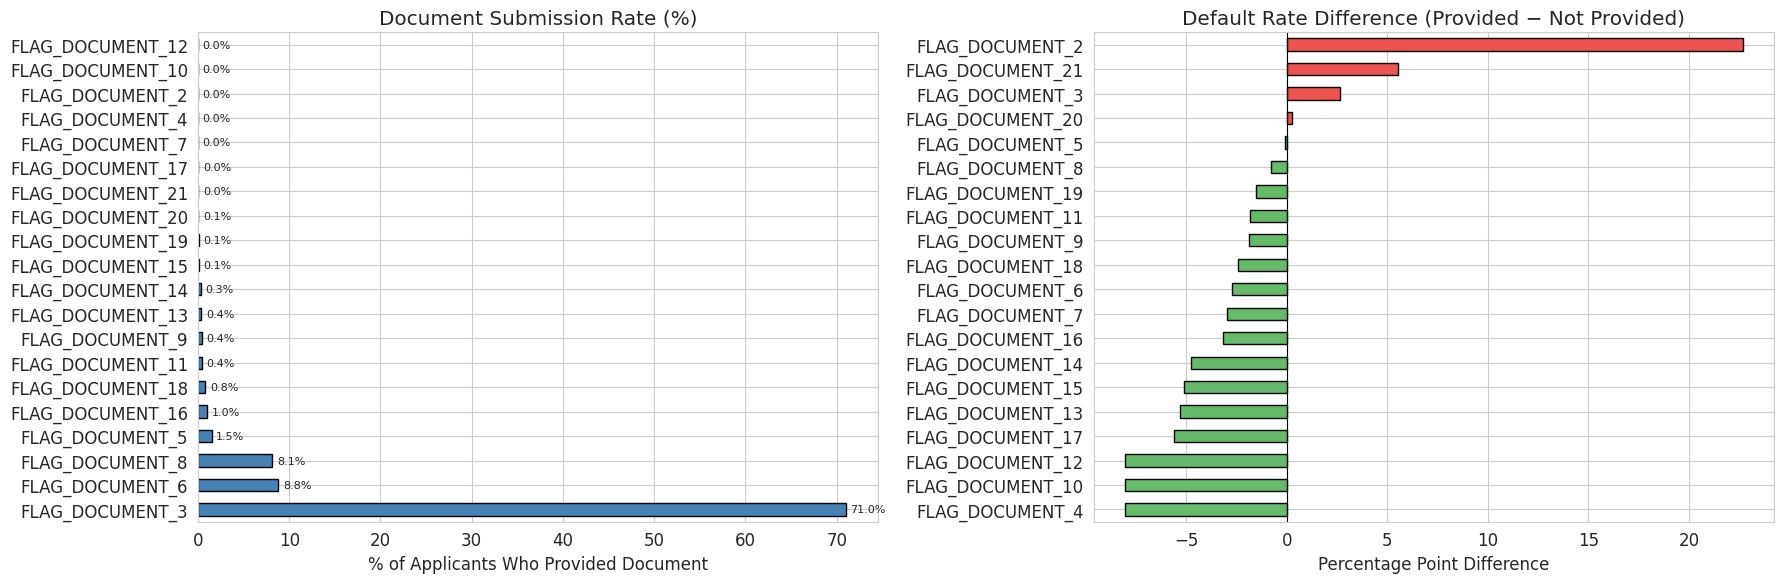


Key observations:
  FLAG_DOCUMENT_3: Submitted by 71.0% of applicants (most common)
  Documents submitted by < 1% of applicants: 16 out of 20


In [63]:
# Analyze FLAG_DOCUMENT columns
doc_cols = [c for c in train.columns if c.startswith('FLAG_DOCUMENT_')]
print(f"Number of FLAG_DOCUMENT columns: {len(doc_cols)}")

# Submission rate for each document
doc_rates = train[doc_cols].mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Document submission rates
doc_rates.plot.barh(ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Document Submission Rate (%)')
axes[0].set_xlabel('% of Applicants Who Provided Document')
for i, v in enumerate(doc_rates.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)

# Default rate by document flag
doc_default_rates = {}
for col in doc_cols:
    doc_default_rates[col] = {
        'Provided': train[train[col] == 1]['TARGET'].mean() * 100,
        'Not Provided': train[train[col] == 0]['TARGET'].mean() * 100
    }
doc_df = pd.DataFrame(doc_default_rates).T
doc_df['Diff'] = doc_df['Provided'] - doc_df['Not Provided']
doc_df.sort_values('Diff', ascending=True, inplace=True)

doc_df['Diff'].plot.barh(ax=axes[1], color=doc_df['Diff'].apply(
    lambda x: '#ef5350' if x > 0 else '#66bb6a'), edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Default Rate Difference (Provided − Not Provided)')
axes[1].set_xlabel('Percentage Point Difference')
plt.tight_layout()
plt.show()

print("\nKey observations:")
print(f"  FLAG_DOCUMENT_3: Submitted by {doc_rates['FLAG_DOCUMENT_3']:.1f}% of applicants (most common)")
rarely_submitted = doc_rates[doc_rates < 1.0]
print(f"  Documents submitted by < 1% of applicants: {len(rarely_submitted)} out of {len(doc_cols)}")

## 19. Other Temporal Features (DAYS_REGISTRATION, DAYS_ID_PUBLISH, DAYS_LAST_PHONE_CHANGE)

These DAYS_* features capture how recently (in negative days) the applicant registered, published their ID document, and changed their phone number. Larger negative values = longer ago.

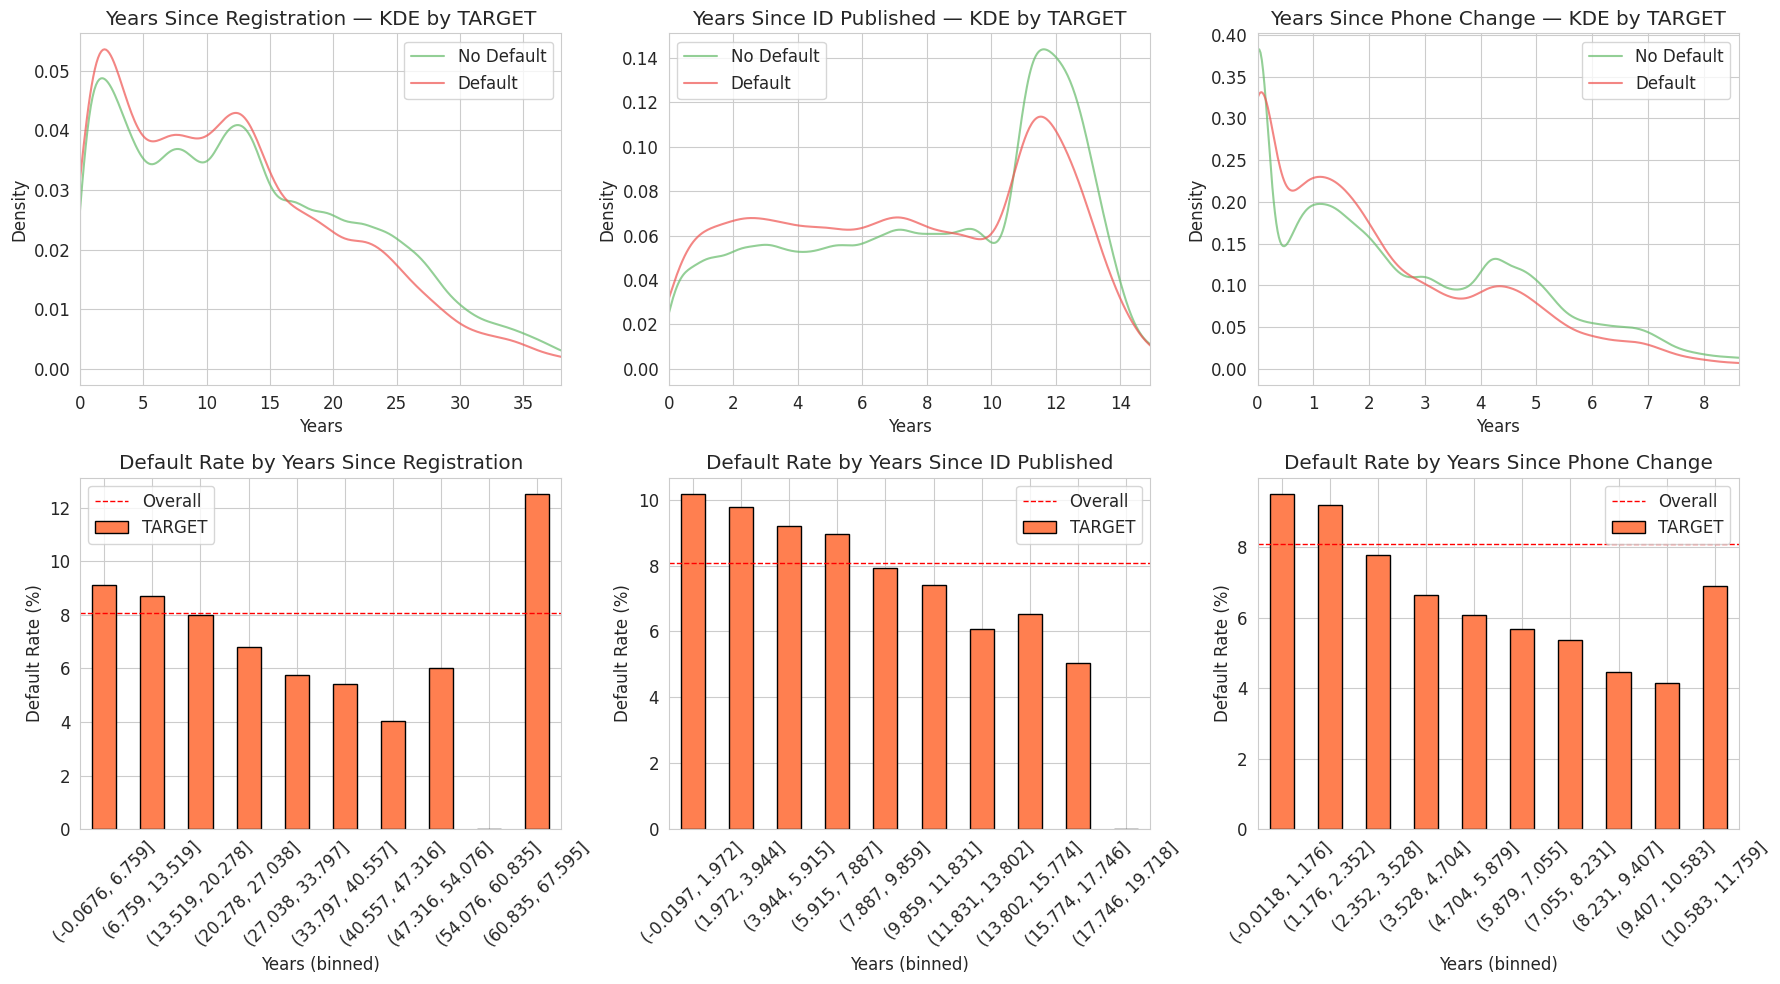

  Years Since Registration                 | Corr with TARGET: 0.0420
  Years Since ID Published                 | Corr with TARGET: 0.0515
  Years Since Phone Change                 | Corr with TARGET: 0.0552


In [65]:
# Analyze other DAYS_* temporal features
days_cols = ['DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']
days_labels = ['Years Since Registration', 'Years Since ID Published', 'Years Since Phone Change']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (col, label) in enumerate(zip(days_cols, days_labels)):
    # Distribution (converted to years)
    years = (train[col] / -365).dropna()

    # KDE by TARGET
    ax_top = axes[0][i]
    for target_val, color, lbl in [(0, '#66bb6a', 'No Default'), (1, '#ef5350', 'Default')]:
        subset = (train[train['TARGET'] == target_val][col] / -365).dropna()
        subset.plot.kde(ax=ax_top, color=color, label=lbl, alpha=0.7)
    ax_top.set_title(f'{label} — KDE by TARGET')
    ax_top.set_xlabel('Years')
    ax_top.legend()
    ax_top.set_xlim(0, years.quantile(0.99))

    # Default rate by binned feature
    ax_bot = axes[1][i]
    train['_temp_bin'] = pd.cut(train[col] / -365, bins=10)
    bin_default = train.groupby('_temp_bin', observed=True)['TARGET'].mean() * 100
    bin_default.plot.bar(ax=ax_bot, color='coral', edgecolor='black')
    ax_bot.axhline(train['TARGET'].mean() * 100, color='red', linestyle='--', linewidth=1, label='Overall')
    ax_bot.set_title(f'Default Rate by {label}')
    ax_bot.set_ylabel('Default Rate (%)')
    ax_bot.set_xlabel('Years (binned)')
    ax_bot.tick_params(axis='x', rotation=45)
    ax_bot.legend()

train.drop(columns='_temp_bin', inplace=True, errors='ignore')
plt.tight_layout()
plt.show()

for col, label in zip(days_cols, days_labels):
    corr = train[col].corr(train['TARGET'])
    print(f"  {label:40s} | Corr with TARGET: {corr:.4f}")

## 20. Credit Bureau Inquiry Features (AMT_REQ_CREDIT_BUREAU_*)

These columns indicate how many times the applicant's credit report was queried by other lenders within different time windows (hour, day, week, month, quarter, year). Frequent inquiries may signal credit-seeking behavior.

Credit Bureau Inquiry columns:
  AMT_REQ_CREDIT_BUREAU_HOUR               | Mean:   0.01 | Missing: 41,519 (13.5%)
  AMT_REQ_CREDIT_BUREAU_DAY                | Mean:   0.01 | Missing: 41,519 (13.5%)
  AMT_REQ_CREDIT_BUREAU_WEEK               | Mean:   0.03 | Missing: 41,519 (13.5%)
  AMT_REQ_CREDIT_BUREAU_MON                | Mean:   0.27 | Missing: 41,519 (13.5%)
  AMT_REQ_CREDIT_BUREAU_QRT                | Mean:   0.27 | Missing: 41,519 (13.5%)
  AMT_REQ_CREDIT_BUREAU_YEAR               | Mean:   1.90 | Missing: 41,519 (13.5%)


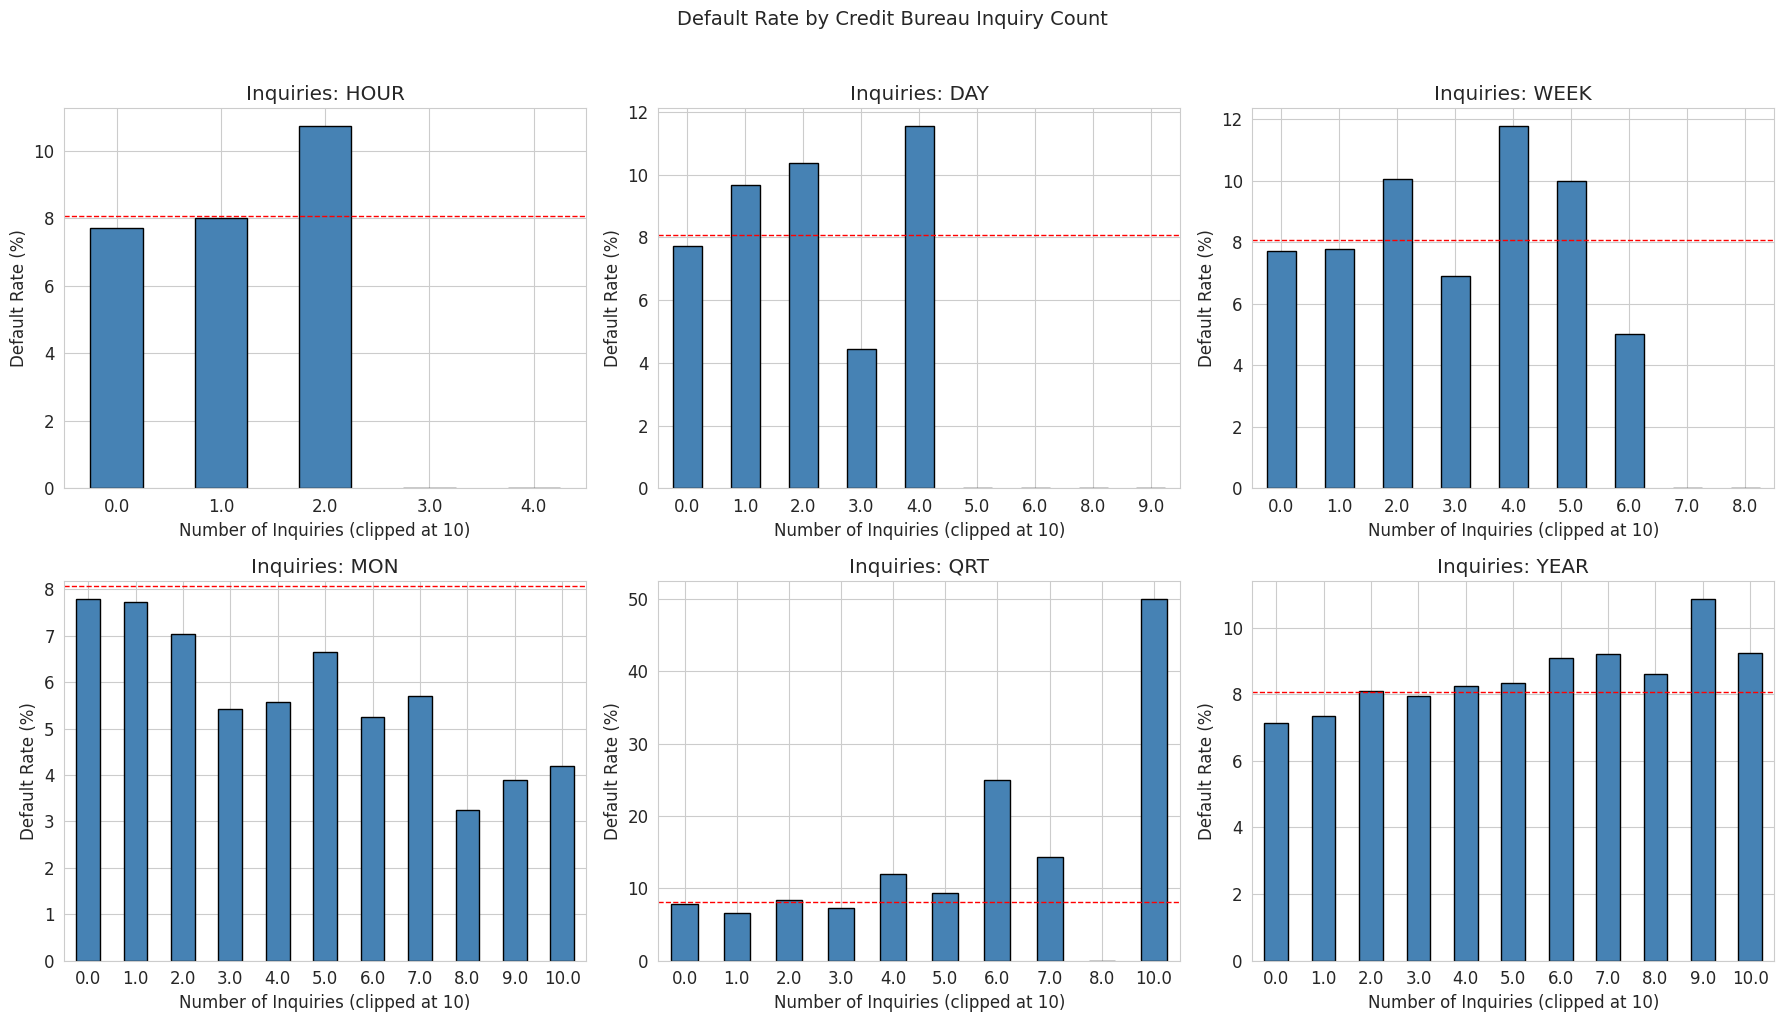


Correlation with TARGET:
  AMT_REQ_CREDIT_BUREAU_HOUR               : 0.0009
  AMT_REQ_CREDIT_BUREAU_DAY                : 0.0027
  AMT_REQ_CREDIT_BUREAU_WEEK               : 0.0008
  AMT_REQ_CREDIT_BUREAU_MON                : -0.0125
  AMT_REQ_CREDIT_BUREAU_QRT                : -0.0020
  AMT_REQ_CREDIT_BUREAU_YEAR               : 0.0199


In [67]:
# Credit Bureau Inquiry features
req_cols = [c for c in train.columns if c.startswith('AMT_REQ_CREDIT_BUREAU_')]
print("Credit Bureau Inquiry columns:")
for col in req_cols:
    non_null = train[col].notna().sum()
    print(f"  {col:40s} | Mean: {train[col].mean():6.2f} | Missing: {train[col].isna().sum():,} ({train[col].isna().mean()*100:.1f}%)")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(req_cols):
    if i >= 6:
        break
    # Default rate by inquiry count
    inquiry_default = train.groupby(train[col].clip(upper=10))['TARGET'].mean() * 100
    inquiry_default.plot.bar(ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].axhline(train['TARGET'].mean() * 100, color='red', linestyle='--', linewidth=1)
    axes[i].set_title(col.replace('AMT_REQ_CREDIT_BUREAU_', 'Inquiries: '))
    axes[i].set_xlabel('Number of Inquiries (clipped at 10)')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Default Rate by Credit Bureau Inquiry Count', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Correlation with TARGET
print("\nCorrelation with TARGET:")
for col in req_cols:
    corr = train[col].corr(train['TARGET'])
    print(f"  {col:40s} : {corr:.4f}")

## 21. Binary Flag Features (Ownership & Contact Flags)

Analyzing binary flag features like `FLAG_OWN_CAR`, `FLAG_OWN_REALTY`, `FLAG_MOBIL`, `FLAG_WORK_PHONE`, `FLAG_PHONE`, `FLAG_EMAIL` and their relationship with default risk.

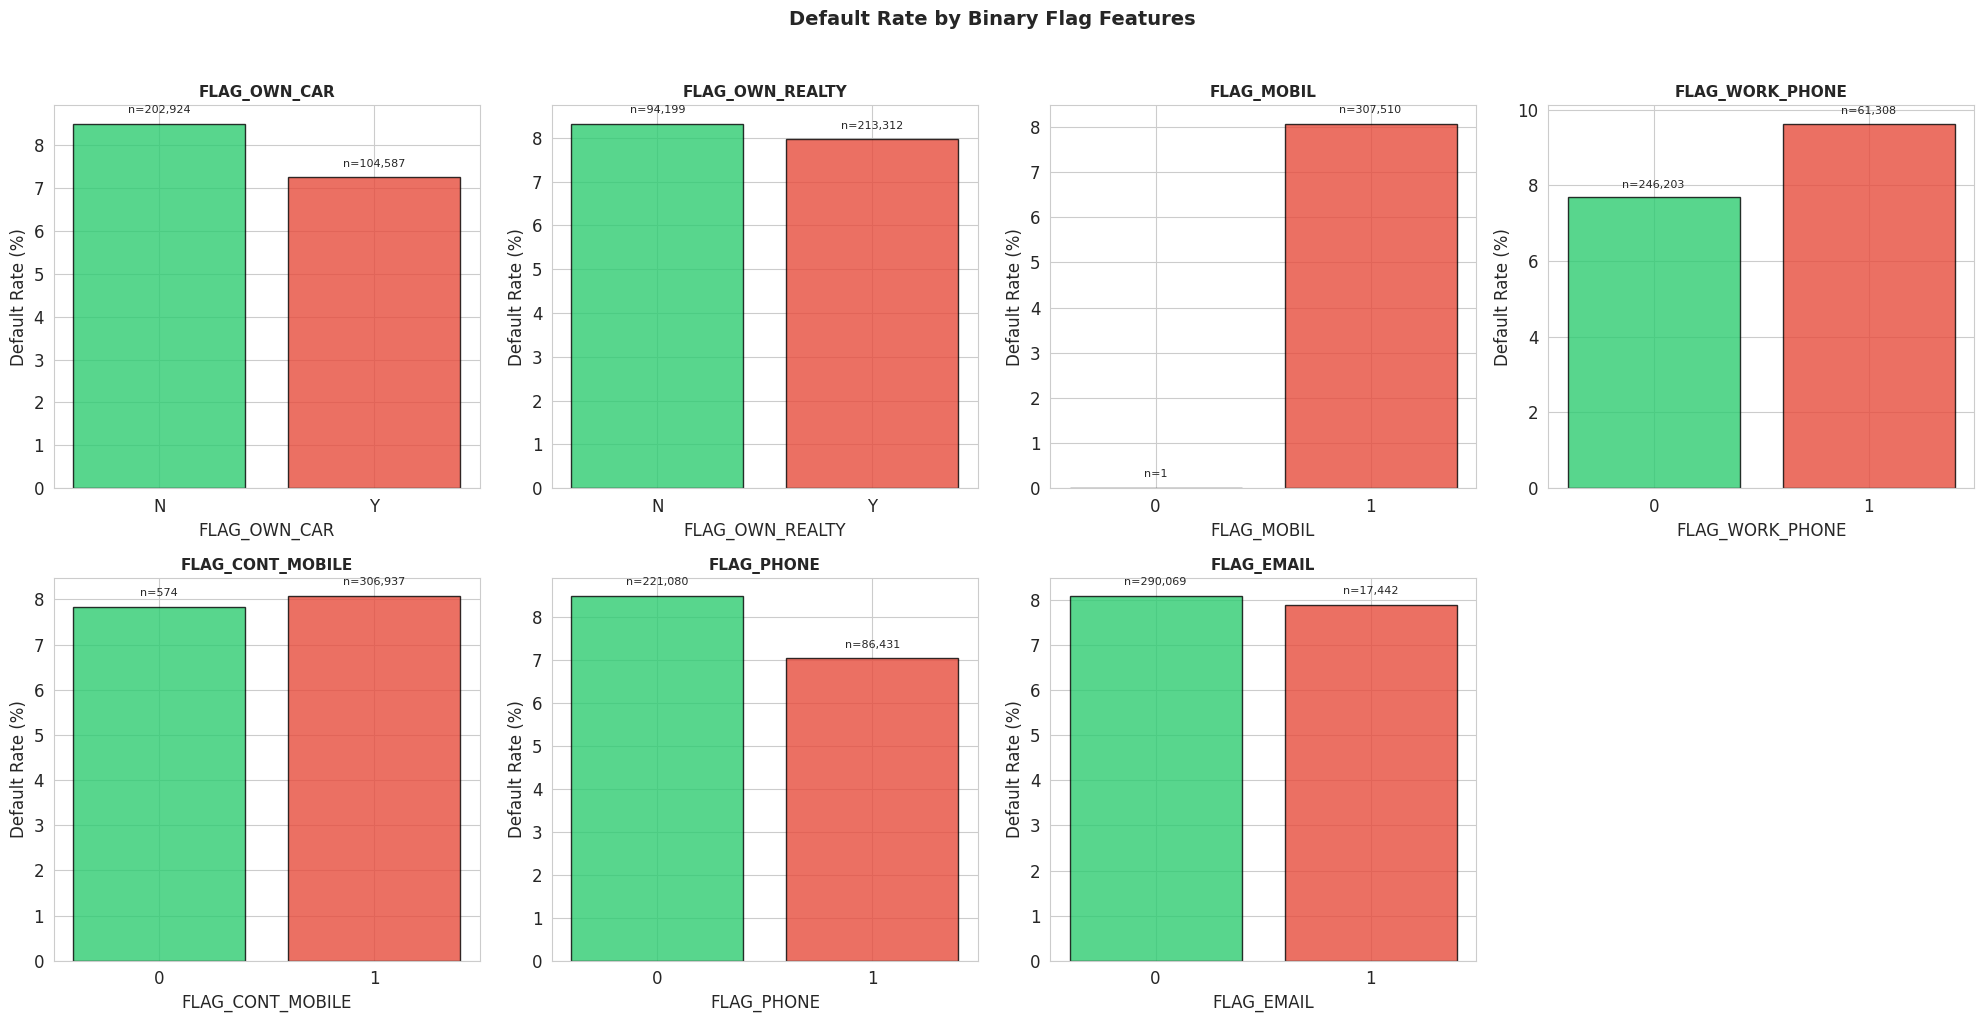


=== Binary Flag Features — Default Rate Summary ===


FLAG_OWN_CAR:
              Default Rate   Count
FLAG_OWN_CAR                      
N                 0.085002  202924
Y                 0.072437  104587

FLAG_OWN_REALTY:
                 Default Rate   Count
FLAG_OWN_REALTY                      
N                    0.083249   94199
Y                    0.079616  213312

FLAG_MOBIL:
            Default Rate   Count
FLAG_MOBIL                      
0               0.000000       1
1               0.080729  307510

FLAG_WORK_PHONE:
                 Default Rate   Count
FLAG_WORK_PHONE                      
0                    0.076851  246203
1                    0.096301   61308

FLAG_CONT_MOBILE:
                  Default Rate   Count
FLAG_CONT_MOBILE                      
0                     0.078397     574
1                     0.080733  306937

FLAG_PHONE:
            Default Rate   Count
FLAG_PHONE                      
0               0.084784  221080
1               0.0

In [71]:
# Binary flag features analysis
flag_cols = ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_MOBIL', 'FLAG_WORK_PHONE',
             'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(flag_cols):
    temp = train.groupby(col)['TARGET'].agg(['mean', 'count']).reset_index()
    temp.columns = [col, 'default_rate', 'count']

    ax = axes[i]
    bars = ax.bar(temp[col].astype(str), temp['default_rate'] * 100,
                  color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Default Rate (%)')
    ax.set_xlabel(col)

    # Add count labels on bars
    for bar, cnt in zip(bars, temp['count']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
                f'n={cnt:,}', ha='center', va='bottom', fontsize=8)

# Remove unused subplot
axes[-1].axis('off')

plt.suptitle('Default Rate by Binary Flag Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print("\n=== Binary Flag Features — Default Rate Summary ===\n")
for col in flag_cols:
    temp = train.groupby(col)['TARGET'].agg(['mean', 'count'])
    temp.columns = ['Default Rate', 'Count']
    temp.index.name = col
    print(f"\n{col}:")
    print(temp.to_string())

## 22. Default Rate by Binned Financial Features

Binning continuous financial features (AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY, AMT_GOODS_PRICE) into deciles and examining default rates across bins. This reveals non-linear relationships with default risk.

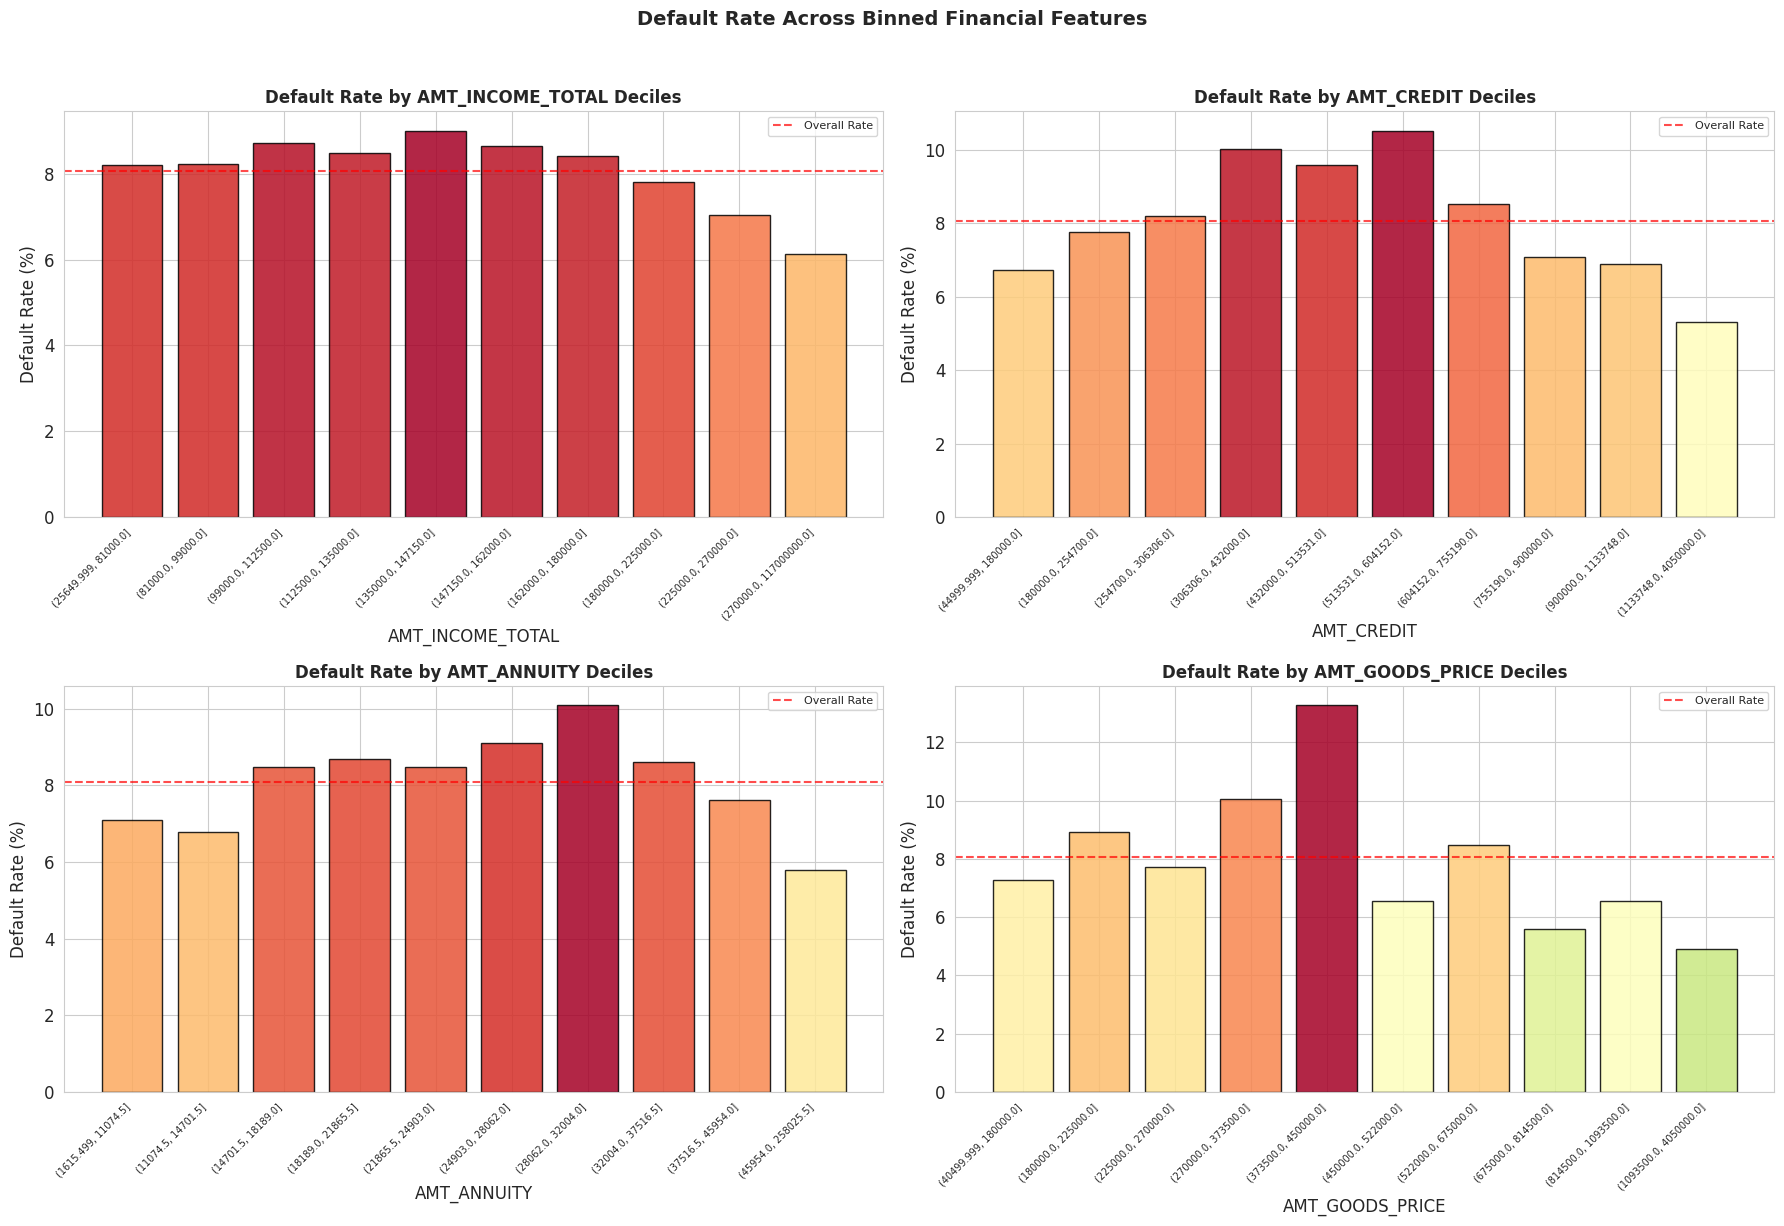

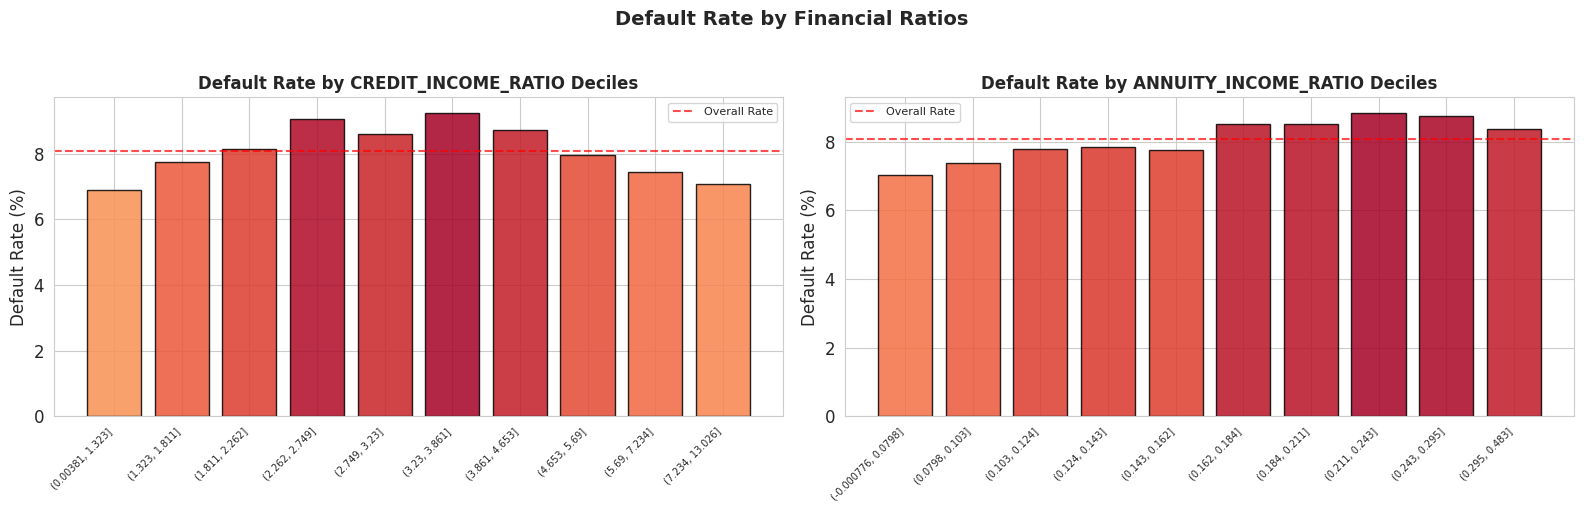

In [73]:
# Default rate by binned financial features
financial_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(financial_cols):
    ax = axes[i]
    temp = train[[col, 'TARGET']].dropna()
    temp[f'{col}_bin'] = pd.qcut(temp[col], q=10, duplicates='drop')

    grouped = temp.groupby(f'{col}_bin', observed=True)['TARGET'].agg(['mean', 'count']).reset_index()
    grouped.columns = ['Bin', 'Default Rate', 'Count']

    # Bar plot for default rate
    color = plt.cm.RdYlGn_r(grouped['Default Rate'] / grouped['Default Rate'].max())
    bars = ax.bar(range(len(grouped)), grouped['Default Rate'] * 100, color=color, edgecolor='black', alpha=0.85)

    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([str(b) for b in grouped['Bin']], rotation=45, ha='right', fontsize=7)
    ax.set_title(f'Default Rate by {col} Deciles', fontsize=12, fontweight='bold')
    ax.set_ylabel('Default Rate (%)')
    ax.set_xlabel(col)
    ax.axhline(y=train['TARGET'].mean() * 100, color='red', linestyle='--', alpha=0.7, label='Overall Rate')
    ax.legend(fontsize=8)

plt.suptitle('Default Rate Across Binned Financial Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Credit-to-income and annuity-to-income ratios
train['CREDIT_INCOME_RATIO'] = train['AMT_CREDIT'] / (train['AMT_INCOME_TOTAL'] + 1)
train['ANNUITY_INCOME_RATIO'] = train['AMT_ANNUITY'] / (train['AMT_INCOME_TOTAL'] + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, col in enumerate(['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO']):
    ax = axes[i]
    temp = train[[col, 'TARGET']].dropna()
    # Cap at 99th percentile for cleaner bins
    cap = temp[col].quantile(0.99)
    temp = temp[temp[col] <= cap]
    temp[f'{col}_bin'] = pd.qcut(temp[col], q=10, duplicates='drop')

    grouped = temp.groupby(f'{col}_bin', observed=True)['TARGET'].agg(['mean', 'count']).reset_index()
    grouped.columns = ['Bin', 'Default Rate', 'Count']

    color = plt.cm.RdYlGn_r(grouped['Default Rate'] / grouped['Default Rate'].max())
    ax.bar(range(len(grouped)), grouped['Default Rate'] * 100, color=color, edgecolor='black', alpha=0.85)
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels([str(b) for b in grouped['Bin']], rotation=45, ha='right', fontsize=7)
    ax.set_title(f'Default Rate by {col} Deciles', fontsize=12, fontweight='bold')
    ax.set_ylabel('Default Rate (%)')
    ax.axhline(y=train['TARGET'].mean() * 100, color='red', linestyle='--', alpha=0.7, label='Overall Rate')
    ax.legend(fontsize=8)

plt.suptitle('Default Rate by Financial Ratios', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Clean up engineered columns
train.drop(columns=['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO'], inplace=True, errors='ignore')

## 17. Summary & Key Findings

### Dataset Overview

| Table | Rows | Columns | Description |
|-------|------|---------|-------------|
| application_train | 307,511 | 122 | Main training set with TARGET |
| application_test | 48,744 | 121 | Test set (no TARGET) |
| bureau | 1,716,428 | 17 | Previous credits from other institutions |
| bureau_balance | 27,299,925 | 3 | Monthly bureau credit balances |
| previous_application | 1,670,214 | 37 | Previous Home Credit loan applications |
| POS_CASH_balance | 10,001,358 | 8 | Monthly POS/cash loan snapshots |
| credit_card_balance | 3,840,312 | 23 | Monthly credit card snapshots |
| installments_payments | 13,605,401 | 8 | Payment history for previous loans |

### Key Observations

1. **Target Imbalance**: ~8% default rate — significant class imbalance requiring techniques like SMOTE, class weights, or stratified sampling.

2. **Missing Values**: Many features have substantial missingness. `COMMONAREA_MEDI/MODE/AVG` and `FONDKAPREMONT_MODE` are missing >65%. External sources (EXT_SOURCE_1) are ~40% missing.

3. **DAYS_EMPLOYED Anomaly**: 365,243 days (~1,000 years) is a sentinel value for ~18% of applicants (likely unemployed/retired). Must be handled before modeling.

4. **Most Predictive Features**: EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 have the strongest negative correlation with TARGET, meaning higher external scores = lower default risk.

5. **Demographic Patterns**:
   - Cash loans dominate (~90%) over revolving loans
   - Females slightly out-number males; males have slightly higher default rates
   - "Working" is the most common income type; "Maternity leave" has the highest default rate
   - "Secondary / secondary special" is the most common education level

6. **Bureau Credits**: Clients have an average of ~8 bureau credits. Most are "Closed" or "Active". Very few have overdue flags.

7. **Previous Applications**: Most previous applications were "Approved", followed by "Canceled" and "Refused". Consumer loans are the most common type.

8. **Payment Behavior**: Most installment payments are made on time or early. A minority of payments are late, but a non-trivial fraction of clients have at least one late payment.

9. **Credit Card Utilization**: Most credit card balances show reasonable utilization ratios, though some clients exceed their credit limits.

10. **Feature Engineering Opportunities**: The supplementary tables offer rich aggregation possibilities (e.g., avg DPD per client, number of previous credits, payment delay statistics) that can significantly improve model performance.

In [74]:
# Final summary statistics
print("=" * 60)
print("  HOME CREDIT DEFAULT RISK — EDA SUMMARY")
print("=" * 60)
print(f"\nTraining samples     : {len(train):,}")
print(f"Features             : {train.shape[1] - 2}")  # excluding SK_ID_CURR and TARGET
print(f"Default rate         : {train['TARGET'].mean():.4f} ({train['TARGET'].mean()*100:.2f}%)")
print(f"Numerical features   : {len(train.select_dtypes(include=[np.number]).columns) - 2}")
print(f"Categorical features : {len(train.select_dtypes(include=['object']).columns)}")
missing_pct = (train.isnull().sum().sum()) / (train.shape[0] * train.shape[1]) * 100
print(f"Overall missing %    : {missing_pct:.2f}%")
print(f"\nTop correlated features with TARGET:")
corr_target = train.select_dtypes(include=[np.number]).corr()['TARGET'].drop('TARGET').abs().sort_values(ascending=False)
for feat, val in corr_target.head(10).items():
    print(f"  {feat:40s} : {val:.4f}")
print("\n" + "=" * 60)
print("  EDA COMPLETE")
print("=" * 60)

  HOME CREDIT DEFAULT RISK — EDA SUMMARY

Training samples     : 307,511
Features             : 120
Default rate         : 0.0807 (8.07%)
Numerical features   : 104
Categorical features : 16
Overall missing %    : 24.40%

Top correlated features with TARGET:
  EXT_SOURCE_3                             : 0.1789
  EXT_SOURCE_2                             : 0.1605
  EXT_SOURCE_1                             : 0.1553
  DAYS_BIRTH                               : 0.0782
  REGION_RATING_CLIENT_W_CITY              : 0.0609
  REGION_RATING_CLIENT                     : 0.0589
  DAYS_LAST_PHONE_CHANGE                   : 0.0552
  DAYS_ID_PUBLISH                          : 0.0515
  REG_CITY_NOT_WORK_CITY                   : 0.0510
  FLAG_EMP_PHONE                           : 0.0460

  EDA COMPLETE
